# BERTopic — Tweets BR Eleições 2022 (PT-BR)

## Visão geral

Pipeline BERTopic sobre o corpus `tweets_bre2022` (PT-BR, texto curto).

**Corpus:** Tweets brasileiros — eleições 2022, PT-BR, informal, ~200k docs, ~23 tokens/doc.
**Entrada:** `data/input/tweets_bre2022/corpus_limpo.csv` + `embeddings_*.npy`


## 1. Setup

In [1]:
# ── path fix: resolve _helpers.py e data/ de qualquer subdiretório ──
import sys as _sys, os as _os
from pathlib import Path as _P
_here = _P().resolve()
_nb_dir = _here if (_here / '_helpers.py').exists() else _here.parent
if str(_nb_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_dir))
_os.chdir(_nb_dir)          # '../data/...' paths ficam corretos
del _here, _nb_dir, _P, _sys, _os
# ─────────────────────────────────────────────────────────────────────
# Cell 1 — Imports
import sys, os, json, time, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from _helpers import load_params, get_corpus_config, get_seed, load_corpus
from _helpers import get_or_compute_embeddings
from _helpers import name_all_topics, name_topic, _fallback_label, _smart_fallback
from _helpers import compute_coherence_npmi, compute_metrics_table, diagnose_cv_window
from _helpers import (
    compute_coherence_cv, compute_exclusivity, compute_topic_diversity,
    compute_exclusivity_ctfidf, compute_embedding_coherence, compute_frex_score,
    export_results, export_topics_for_eval,
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

D:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 2 — Params
CORPUS_ID = "tweets_bre2022"

params = load_params()
_, cfg = get_corpus_config(params, CORPUS_ID)
seed = get_seed(params)
TEXT_COL = cfg["text_column"]

from _helpers import make_run_output_dir
# Subpasta bertopic/ separa runs por modelo (espelha folha migrado)
BASE_RESULTS_DIR = Path(f"../data/output/{CORPUS_ID}/bertopic")
BASE_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
# Saida carimbada por execucao: <corpus>_<data>_<hora> (nao sobrescreve runs anteriores)
RESULTS_DIR = make_run_output_dir(BASE_RESULTS_DIR, CORPUS_ID)

print(f"corpus_id    = {CORPUS_ID}")
print(f"text_column  = {TEXT_COL}")
print(f"language     = {cfg.get('language', 'pt')}")
print(f"bertopic_lang= {cfg.get('bertopic_language', 'multilingual')}")
print(f"seed         = {seed}")
print(f"output       = {RESULTS_DIR}")

corpus_id    = tweets_bre2022
text_column  = message
language     = pt
bertopic_lang= multilingual
seed         = 42
output       = ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804


## 2. Corpus — Tweets BR Eleições 2022

### Origem e preprocessing

- **Fonte**: Zenodo 14834749 (104 parquets, ~7M tweets brutos organizados por hashtag/query)
- **Filtros aplicados**: `is_retweet=False`, dedup por `tweet_id`, dedup por `message`, `min_words=10`
- **Amostra**: 200k tweets estratificados por mês (Ago-Dez 2022)
- **Limpeza**: `clean_text(demojize_pt)` — emojis → tokens PT-BR, remove RT prefix, URLs, @mentions, #

### Fases eleitorais (ground-truth temporal)

| Mês | Fase |
|---|---|
| 2022-08 | Campanha 1º turno (início) |
| 2022-09 | Campanha intensa + 1º turno (02/out) |
| 2022-10 | Entre-turnos + 2º turno (30/out) |
| 2022-11 | Pós-eleição (resultado + transição) |
| 2022-12 | Transição + protestos |

In [3]:
# Cell 3 — Load corpus (latest-wins: le diretamente do output do 01-preprocessing)
from _helpers import resolve_latest_dir

_corpus_base = Path(f"../../01-preprocessing/data/output/{CORPUS_ID}")
_corpus_dir  = resolve_latest_dir(
    _corpus_base,
    contains="corpus_limpo.csv",
    fallback_dir=Path(f"../data/input/{CORPUS_ID}"),
)
print(f"Versao do corpus: {_corpus_dir.name}")

df = load_corpus(str(_corpus_dir) + "/")
docs     = df[TEXT_COL].astype(str).tolist()
docs_raw = df.get("message_raw", df[TEXT_COL]).astype(str).tolist()
post_ids = df["post_id"].astype(str).tolist()

print(f"Total docs: {len(docs):,}")
print(f"Colunas: {list(df.columns)}")
df.head(3)

  versão resolvida: tweets_bre2022_20260629_215159/ (latest)
Versao do corpus: tweets_bre2022_20260629_215159


Carregado: corpus_limpo.csv (8811 docs, SEM coluna 'sentiment' — rode 03-sentiment antes para ter cruzamento topic x sentiment automatico)
Total docs: 8,811
Colunas: ['tweet_id', 'message', 'message_raw', 'post_id', 'data', 'user', 'user_info', 'has_mention', 'mentions', 'is_reply', 'reply_to', 'is_quote', 'quoted_from', 'is_retweet', 'retweeted_from', 'hashtags', 'native_mentions', 'retweet_mentions', 'Unnamed: 0', 'platform', 'election', 'category']


,tweet_id,message,message_raw,post_id,data,user,user_info,has_mention,mentions,is_reply,...,quoted_from,is_retweet,retweeted_from,hashtags,native_mentions,retweet_mentions,Unnamed: 0,platform,election,category
0,1562979518280699904,"@LulaOficial “Lulinha”, “Alckmin”, “Paulo Frei...","@LulaOficial “Lulinha”, “Alckmin”, “Paulo Frei...",tw_00044339,2022-08-26 01:45:30,luciana_onofre,"{'id': 2853238599, 'name': 'Luciana Lula da Si...",True,"[{'id': '2670726740', 'username': 'LulaOficial'}]",False,...,NaN,True,"{'user': 'UOLNoticias', 'user_id': 14594698, '...","['#LADRAONOJN', '#LulaNoJN']",NaN,NaN,NaN,twitter,br_2022,2022-08
1,1562053466830389249,@jairbolsonaro @Anitta Bora da aquela pesquisa...,@jairbolsonaro @Anitta Bora da aquela pesquisa...,tw_00073680,2022-08-23 12:25:42,mafra_leoni,"{'id': 1479929106804482048, 'name': 'Leoni Gar...",True,"[{'id': '128372940', 'username': 'jairbolsonar...",False,...,NaN,True,"{'user': 'Jouberth19', 'user_id': 350476403, '...",['#GloboLixo'],NaN,NaN,NaN,twitter,br_2022,2022-08
2,1561862082315837440,Hoje eu tô muito Bonnerzete e Renatete! #Jorna...,Hoje eu tô muito Bonnerzete e Renatete! #Jorn...,tw_00102132,2022-08-22 23:45:13,vieradriano,"{'id': 1349339460027211777, 'name': 'Adrianno ...",False,NaN,False,...,NaN,True,"{'user': 'tvlizando', 'user_id': 2471757957, '...","['#JornalNacional', '#JN', '#ForaBolsonaro']",NaN,NaN,NaN,twitter,br_2022,2022-08


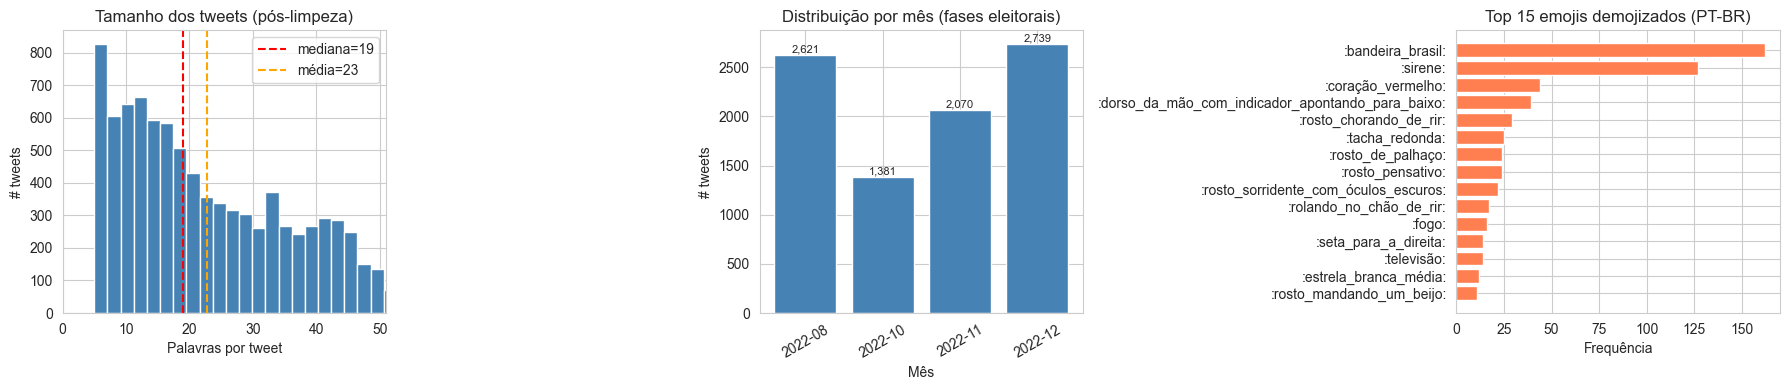


Descritivas: {'count': 8811.0, 'mean': 22.75939166950403, 'std': 13.05769920589274, 'min': 5.0, '25%': 12.0, '50%': 19.0, '75%': 33.0, 'max': 88.0}


In [4]:
# Cell 4 — Distribuição temporal + tamanho dos tweets
df["n_tokens"] = df["message"].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Histograma tamanho
axes[0].hist(df["n_tokens"], bins=40, edgecolor="white", color="steelblue")
axes[0].axvline(df["n_tokens"].median(), color="red", linestyle="--",
                label=f'mediana={df["n_tokens"].median():.0f}')
axes[0].axvline(df["n_tokens"].mean(), color="orange", linestyle="--",
                label=f'média={df["n_tokens"].mean():.0f}')
axes[0].set_xlabel("Palavras por tweet"); axes[0].set_ylabel("# tweets")
axes[0].set_title("Tamanho dos tweets (pós-limpeza)"); axes[0].legend()
axes[0].set_xlim(0, df["n_tokens"].quantile(0.99))

# Distribuição por mês
month_counts = df["category"].value_counts().sort_index()
axes[1].bar(month_counts.index, month_counts.values, color="steelblue")
axes[1].set_xlabel("Mês"); axes[1].set_ylabel("# tweets")
axes[1].set_title("Distribuição por mês (fases eleitorais)")
axes[1].tick_params(axis="x", rotation=30)
for i, c in enumerate(month_counts.values):
    axes[1].text(i, c + max(month_counts)*0.01, f"{c:,}", ha="center", fontsize=8)

# Top emojis demojizados (tokens que começam com :)
import re as re_
all_tokens = " ".join(docs).split()
emoji_tokens = [t for t in all_tokens if re_.match(r'^:[a-zA-ZÀ-ÿ_]+:$', t)]
top_emojis = pd.Series(emoji_tokens).value_counts().head(15)
axes[2].barh(top_emojis.index[::-1], top_emojis.values[::-1], color="coral")
axes[2].set_title("Top 15 emojis demojizados (PT-BR)")
axes[2].set_xlabel("Frequência")

plt.tight_layout(); plt.show()
print(f"\nDescritivas: {df['n_tokens'].describe().to_dict()}")

## 3. Embeddings semânticos

`qwen3-embedding:0.6b` (Ollama, 1024d nativo, Matryoshka desabilitado). **Nota de tempo**: 200k tweets a ~2k/min ≈ 100 min no 1º run. Re-runs usam cache .npy (~5s).

In [5]:
# Cell 5 — BERTopic config params + embeddings
bert_cfg   = params["bertopic"]
from _helpers import apply_bertopic_overrides
bert_cfg   = apply_bertopic_overrides(bert_cfg, cfg)  # aplica bertopic_overrides do corpus (params.yaml)
emb_model  = bert_cfg["embedding_model"]
emb_dim    = bert_cfg.get("embedding_dimension")  # None → nativo
safe_model = re.sub(r'[/:\\?*"<>|]', '_', emb_model)
emb_suffix = bert_cfg.get("embedding_suffix", "4096d")
emb_file   = f"embeddings_{safe_model}_{emb_suffix}.npy"

# Latest-wins: resolve subpasta carimbada mais recente no output do 02-embeddings
_emb_base = Path(f"../../02-embeddings/data/output/{CORPUS_ID}")
_emb_dir  = resolve_latest_dir(
    _emb_base,
    contains=emb_file,
    fallback_dir=_emb_base,          # fallback: layout plano legado
)
cache_path = _emb_dir / emb_file
print(f"Versao dos embeddings: {_emb_dir.name}")
print(f"dim={emb_dim or 'nativo 4096d'}")

# O 03 NAO computa embeddings inline — essa responsabilidade e exclusiva do
# 02-embeddings (que ja trata num_ctx/contexto para documentos longos). Aqui
# so carregamos o cache .npy ja versionado.
assert cache_path.exists(), (
    f"Embeddings nao encontrados em {cache_path}. Rode "
    "02-embeddings/notebooks/02_embeddings.ipynb para este corpus antes do BERTopic."
)
embeddings = np.load(cache_path)
print(f"embeddings: shape={embeddings.shape}")

  versão resolvida: tweets_bre2022_20260725_183835/ (latest)
Versao dos embeddings: tweets_bre2022_20260725_183835
dim=nativo 4096d


embeddings: shape=(8811, 4096)


## 4. BERTopic — fit + pós-processamento


In [6]:
# Cell 6 — Configurar BERTopic
from bertopic import BERTopic
from bertopic.representation import MaximalMarginalRelevance
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

vec_params = bert_cfg["vectorizer"]
vectorizer = CountVectorizer(
    ngram_range=tuple(vec_params["ngram_range"]),
    token_pattern=cfg.get("token_pattern", r"(?u)\b[a-zA-ZÀ-ÿ_]{2,}\b"),
    max_df=0.5,
)

umap_params = bert_cfg["umap"]
umap_model = UMAP(
    n_components=umap_params["n_components"],
    n_neighbors=umap_params["n_neighbors"],
    min_dist=umap_params["min_dist"],
    metric=umap_params["metric"],
    random_state=seed,
    verbose=True,
)

hdbscan_params = bert_cfg["hdbscan"]
hdbscan_model = HDBSCAN(
    min_cluster_size=hdbscan_params["min_cluster_size"],
    min_samples=hdbscan_params["min_samples"],
    cluster_selection_method=hdbscan_params["cluster_selection_method"],
    prediction_data=True,
)

topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    # MMR como ASPECTO, nao a representacao Main: get_topic(tid) (sem full=True)
    # continua devolvendo o c-TF-IDF puro -- o que toda metrica de qualidade deve
    # consumir; a lista diversificada fica em get_topic(tid, full=True)["MMR"] para
    # quem precisa dela -- nomeacao via LLM e leitura humana.
    representation_model={"MMR": MaximalMarginalRelevance(
        diversity=bert_cfg["mmr_diversity"],
        top_n_words=params["evaluation"].get("top_n_words_cache", 100),
    )},
    min_topic_size=bert_cfg["min_topic_size"],
    language=cfg.get("bertopic_language", "multilingual"),
    calculate_probabilities=False,
    verbose=True,
)
print("BERTopic configurado.")

BERTopic configurado.


In [7]:
# Cell 9b — GUARDA DO PROTOCOLO: a configuracao ativa e a admissivel? (2026-08-16)
# ---------------------------------------------------------------------------
# O artigo base escolhia a configuracao por escore composto e a copiava a mao para
# params.yaml > corpora.<id>.bertopic_overrides. Dois riscos, os dois ja realizados
# neste projeto: (a) o override herdado de outro corpus por bug de wiring, que fez
# os tweets rodarem com os parametros da folha; (b) o criterio declarado no artigo
# nao descrever o procedimento executado (protocolo secao 3.2, resultado 2).
#
# Esta celula fecha o passo manual: se _selecao.py ja rodou, ela confere que a
# configuracao ATIVA -- lida dos OBJETOS que vao rodar, nao dos dicts de config --
# e a que as restricoes A1/A3/A4 + Pareto + desempate elegeram, e PARA se divergir.
# Nao escolhe nada: so impede que a escolha seja esquecida.
from pathlib import Path as _Path

_cid = globals().get("corpus_id") or globals().get("CORPUS_ID")
_sel_path = _Path(f"../data/output/{_cid}/bertopic/selecao_bertopic.csv")

_umap = next((globals()[n] for n in ("umap_model", "umap") if n in globals()), None)
_hdb = next((globals()[n] for n in ("hdbscan_model", "hdb_model", "hdb", "cluster_model")
             if n in globals()), None)
if _umap is None or _hdb is None:
    raise RuntimeError(
        "guarda do protocolo: nao encontrei os objetos UMAP/HDBSCAN nesta sessao. "
        "Esta celula precisa vir DEPOIS da celula que os constroi."
    )

_ativo = {
    "n_neighbors": int(_umap.n_neighbors),
    "min_cluster_size": int(_hdb.min_cluster_size),
    "min_samples": (None if getattr(_hdb, "min_samples", None) is None
                    else int(_hdb.min_samples)),
    "cluster_selection_method": str(getattr(_hdb, "cluster_selection_method", "eom")),
}
print("Configuracao ATIVA (lida dos objetos):")
for _k, _v in _ativo.items():
    print(f"    {_k:26s} {_v!r}")

if not _sel_path.exists():
    print("\nAVISO: selecao_bertopic.csv ausente — rode primeiro:")
    print(f"    venv\\Scripts\\python 03-topic-modeling/notebooks/_selecao.py bertopic {_cid}")
    print("A configuracao acima NAO passou pela camada de admissibilidade do protocolo.")
else:
    _sel = pd.read_csv(_sel_path)
    _esc = _sel[_sel["escolhida"] == True] if "escolhida" in _sel.columns else _sel.head(0)
    if _esc.empty:
        raise ValueError(f"{_sel_path} sem linha 'escolhida' — rode _selecao.py de novo")
    _e = _esc.iloc[0]

    def _mesmo(_v, _alvo):
        if _v is None:
            return pd.isna(_alvo)
        if pd.isna(_alvo):
            return False
        if isinstance(_v, int):
            return int(float(_alvo)) == _v
        return str(_alvo).strip() == str(_v).strip()

    _div = [f"{_k}: ativo={_v!r} vs protocolo={_e[_k]!r}"
            for _k, _v in _ativo.items() if not _mesmo(_v, _e[_k])]

    print("\nConfiguracao ELEITA pelo protocolo:")
    for _k in _ativo:
        print(f"    {_k:26s} {_e[_k]!r}")
    print(f"    K={_e.get('K')}  n_raw={_e.get('n_raw')}  razao_nraw_k={_e.get('razao_nraw_k')}")
    print(f"    cobertura={_e.get('cobertura')}  NPMI={_e.get('NPMI')}  "
          f"Diversity={_e.get('Diversity')}")
    print(f"    reduce_nr eleito: {_e.get('reduce_nr')} — confira o reduce_topics adiante")

    if _div:
        raise ValueError(
            "A configuracao ativa DIVERGE da eleita pelo protocolo:\n  "
            + "\n  ".join(_div)
            + f"\n\nAtualize corpora.{_cid}.bertopic_overrides no params.yaml para a "
            "configuracao eleita, ou rode _selecao.py de novo se a grade mudou. Nao "
            "contorne esta checagem: ela existe porque o criterio declarado tem de "
            "descrever o procedimento executado."
        )
    print("\nOK — a configuracao ativa e a admissivel eleita pelo protocolo.")


Configuracao ATIVA (lida dos objetos):
    n_neighbors                10
    min_cluster_size           40
    min_samples                5
    cluster_selection_method   'eom'

Configuracao ELEITA pelo protocolo:
    n_neighbors                10
    min_cluster_size           40
    min_samples                5.0
    cluster_selection_method   'eom'
    K=24  n_raw=39  razao_nraw_k=1.625
    cobertura=0.8943366246737035  NPMI=0.1869117221465717  Diversity=0.45
    reduce_nr eleito: 25 — confira o reduce_topics adiante

OK — a configuracao ativa e a admissivel eleita pelo protocolo.


In [8]:
# Cell 7 — Fit
t0 = time.time()
topics, _ = topic_model.fit_transform(docs, embeddings)
print(f"\nfit_transform done {time.time()-t0:.0f}s")
print(f"raw topics (HDBSCAN): {len(set(topics))}")
print(f"raw outlier rate: {(np.array(topics)==-1).sum()/len(topics):.3f}")

2026-08-29 11:28:31,447 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.0, n_components=5, n_jobs=1, n_neighbors=10, random_state=42, verbose=True)


Sat Aug 29 11:28:31 2026

 Construct fuzzy simplicial set


Sat Aug 29 11:28:31 2026 Finding Nearest Neighbors


...

2026-08-29 11:29:36,518 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-08-29 11:29:36,936 - BERTopic - Cluster - Completed ✓


2026-08-29 11:29:36,944 - BERTopic - Representation - Extracting topics from clusters using representation models.


2026-08-29 11:29:38,645 - BERTopic - Representation - Completed ✓



fit_transform done 68s
raw topics (HDBSCAN): 40
raw outlier rate: 0.106


In [9]:
# Cell 8 — Pós-processamento BERTopic (4 etapas — ordem obrigatória):
#   1. reduce_outliers  → retorna novos assignments
#   2. update_topics    → sincroniza o modelo (obrigatório antes de reduce_topics)
#   3. reduce_topics    → consolida granularidade fina para nr_target
#   4. update_topics    → refresca representações c-TF-IDF após a redução

representation_model = topic_model.representation_model

ro_cfg   = bert_cfg["reduce_outliers"]
ro_on    = ro_cfg.get("enabled", True)
ro_strat = ro_cfg.get("strategy", "c-tf-idf")
ro_thr   = ro_cfg.get("threshold", 0.0)
nr_topics = bert_cfg.get("reduce_topics_nr", 30)

n_total = len(topics)
n_out_pre = int((np.array(topics) == -1).sum())
print(f"Fit inicial: {len(set(topics)) - 1} tópicos, {n_out_pre} outliers ({n_out_pre/n_total*100:.1f}%)")

if ro_on:
    print(f"reduce_outliers(strategy='{ro_strat}', threshold={ro_thr}): reatribuindo {n_out_pre} outliers...")
    new_topics = topic_model.reduce_outliers(
        docs, topics,
        strategy=ro_strat,
        threshold=ro_thr,
    )
    topic_model.update_topics(
        docs, topics=new_topics,
        vectorizer_model=vectorizer,
        representation_model=representation_model,
    )
    topics = new_topics
    n_out_post = int((np.array(topics) == -1).sum())
    print(f"Após reduce_outliers: {n_out_post} outliers remanescentes")
else:
    print("reduce_outliers: desabilitado.")

print(f"reduce_topics(nr_topics={nr_topics})...")
topic_model.reduce_topics(docs, nr_topics=nr_topics)
new_topics = topic_model.topics_
topic_model.update_topics(
    docs, topics=new_topics,
    vectorizer_model=vectorizer,
    representation_model=representation_model,
)
topics = new_topics

topic_info   = topic_model.get_topic_info()
n_topics     = len([t for t in topic_info["Topic"].tolist() if t != -1])
n_out_final  = int((np.array(topics) == -1).sum())
outlier_rate = n_out_final / n_total
coverage     = 1 - outlier_rate

print(f"\nFinal: {n_topics} tópicos | {n_out_final} outliers ({outlier_rate*100:.1f}%)")
print(f"Cobertura: {coverage*100:.1f}%")
print(topic_info[topic_info["Topic"] != -1][["Topic", "Count", "Name"]].head(15).to_string(index=False))

2026-08-29 11:29:39,262 - BERTopic - Topic reduction - Reducing number of topics


Fit inicial: 39 tópicos, 931 outliers (10.6%)
reduce_outliers: desabilitado.
reduce_topics(nr_topics=25)...


2026-08-29 11:29:40,860 - BERTopic - Topic reduction - Reduced number of topics from 40 to 25


2026-08-29 11:29:41,304 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.



Final: 24 tópicos | 931 outliers (10.6%)
Cobertura: 89.4%
 Topic  Count                                                                                  Name
     0   1681                                         0_em brasília_infiltrados_terroristas_cacique
     1   1208                     1_lulapresidente_lulapresidente https_coração_vermelho_diplomação
     2    669                                     2_debatenaband_ciro_debatenaband https_lulanaband
     3    541                                             3_globolixo_globolixo https_em casa_puder
     4    433                                              4_mané não_barroso_amola https_co perdeu
     5    425                          5_ladraonojn_bolsonaro ladrão_ladrão bolsonaro_forabolsonaro
     6    405                            6_rodoviária_rodoviária federal_polícia rodoviária_polícia
     7    381                                            7_eduardo_eduardo bolsonaro_catar_no catar
     8    350 8_bolsonaroreeleito_bandeir

## 5. Tópicos descobertos

In [10]:
# Cell 9 — Extrair keywords
eval_cfg      = params["evaluation"]
top_n_cache   = eval_cfg.get("top_n_words_cache", 100)
top_n_metrics = eval_cfg.get("top_n_keywords_metrics", 20)
top_n_llm     = eval_cfg.get("top_n_keywords_llm", 50)
top_n_viz     = eval_cfg.get("top_n_keywords_viz", 30)
top_n_npmi    = eval_cfg.get("top_n_keywords_npmi", 100)
top_n         = eval_cfg.get("top_n_keywords", 10)    # retrocompat

# topics_keywords: MMR (diversificado) -- nomeacao via LLM e leitura humana.
# topics_keywords_ctfidf: c-TF-IDF puro -- TODA metrica de qualidade (coerencia,
# diversidade, exclusividade, FREX) deve consumir esta, nunca a MMR (que ja
# otimiza diversidade do top-N; medir Diversity dela seria circular).
topics_keywords = {}
topics_keywords_ctfidf = {}
for tid in sorted(set(topics)):
    if tid == -1: continue
    kws_ctfidf = topic_model.get_topic(tid)
    if kws_ctfidf:
        topics_keywords_ctfidf[tid] = [w for w, _ in kws_ctfidf[:top_n_cache]]
    kws_mmr = topic_model.get_topic(tid, full=True)["MMR"]
    if kws_mmr:
        topics_keywords[tid] = [w for w, _ in kws_mmr[:top_n_cache]]

valid_ids = list(topics_keywords.keys())
K = len(valid_ids)
print(f"K = {K} tópicos válidos\n")
print(f"Cache de keywords por tópico: até {top_n_cache}")
print(f"Slice para métricas:  top-{top_n_metrics}")
print(f"Slice para LLM:       top-{top_n_llm}")
print(f"Slice para wordcloud: top-{top_n_viz}")
print()
for tid in sorted(topics_keywords)[:3]:
    print(f"  T{tid:2d} (top-6 das {len(topics_keywords[tid])} cacheadas): {topics_keywords[tid][:6]}")

K = 24 tópicos válidos

Cache de keywords por tópico: até 100
Slice para métricas:  top-20
Slice para LLM:       top-50
Slice para wordcloud: top-30

  T 0 (top-6 das 30 cacheadas): ['em brasília', 'infiltrados', 'terroristas', 'cacique', 'fogo', 'manifestantes']
  T 1 (top-6 das 30 cacheadas): ['lulapresidente', 'lulapresidente https', 'coração_vermelho', 'diplomação', 'nordeste', 'deixem']
  T 2 (top-6 das 30 cacheadas): ['debatenaband', 'ciro', 'debatenaband https', 'lulanaband', 'debate', 'simone']


In [11]:
# c-TF-IDF completa → topic_word_scores (exclusividade corrigida F1)
# A matriz completa evita superestimar exclusividade ao usar apenas top-N do próprio tópico.
ctfidf_full = topic_model.c_tf_idf_.toarray() if topic_model.c_tf_idf_ is not None else None
vocab_full  = topic_model.vectorizer_model.get_feature_names_out()
_all_tids_excl  = sorted(topic_model.get_topics().keys())
_topic_idx_excl = {t: i for i, t in enumerate(_all_tids_excl)}

topic_word_scores: dict = {}
if ctfidf_full is not None:
    for tid in topics_keywords_ctfidf:
        if tid in _topic_idx_excl:
            row = ctfidf_full[_topic_idx_excl[tid]]
            topic_word_scores[tid] = {
                vocab_full[j]: float(row[j]) for j in range(len(vocab_full)) if row[j] > 0
            }
        else:
            topic_word_scores[tid] = {}
else:
    for tid in topics_keywords_ctfidf:
        topic_word_scores[tid] = {w: float(s) for w, s in topic_model.get_topic(tid)}

# ctfidf_matrix + vocab_index + topic_index (para FREX e robustez top-N)
ctfidf_matrix = topic_model.c_tf_idf_.toarray() if topic_model.c_tf_idf_ is not None else np.zeros((1, 1))
vocab         = topic_model.vectorizer_model.get_feature_names_out()
vocab_index   = {w: i for i, w in enumerate(vocab)}
_all_tids_sorted = sorted(topic_model.get_topics().keys())
topic_index   = {tid: i for i, tid in enumerate(_all_tids_sorted)}

mean_frex, frex_per_topic = compute_frex_score(
    topics_keywords_ctfidf,
    topic_word_matrix=ctfidf_matrix,
    vocab_index=vocab_index,
    topic_index=topic_index,
    top_n=top_n_metrics,
    w_freq=0.5,
)
print(f"FREX médio (top-{top_n_metrics}, w_freq=0.5): {mean_frex:.4f}")

mean_excl_ctfidf, excl_per_topic = compute_exclusivity_ctfidf(
    topics_keywords_ctfidf, topic_word_scores, top_n=top_n_metrics
)
print(f"Exclusividade média (top-{top_n_metrics}, c-TF-IDF completo): {mean_excl_ctfidf:.4f}")

# _embed: wrapper agnóstico ao backend para coerência semântica e robustez sweep.
# A Coerência Semântica usa modelo dedicado (eval_cfg.semantic_coherence_embedding_model),
# desacoplado do 8B dos documentos — pesado demais p/ centenas de requisições curtas.
_emb_backend = bert_cfg.get("embedding_backend", "ollama")
_coh_model = eval_cfg.get("semantic_coherence_embedding_model") or emb_model
print(f"Coerência Semântica usando modelo de embedding: {_coh_model}")
if _emb_backend == "ollama":
    from _helpers import get_ollama_embeddings
    def _embed(texts):
        return get_ollama_embeddings(list(texts), _coh_model, dimension=None, max_concurrent=1)
else:
    from sentence_transformers import SentenceTransformer
    _st_model = SentenceTransformer(_coh_model)
    def _embed(texts):
        return _st_model.encode(list(texts), show_progress_bar=False, convert_to_numpy=True)

_topics_kws_metrics = {tid: kws[:top_n_metrics] for tid, kws in topics_keywords_ctfidf.items()}
sem_coh = compute_embedding_coherence(_topics_kws_metrics, _embed)
print(f"Coerência Semântica (top-{top_n_metrics}): {sem_coh:.4f}")

FREX médio (top-20, w_freq=0.5): 0.9830
Exclusividade média (top-20, c-TF-IDF completo): 0.7397
Coerência Semântica usando modelo de embedding: qwen3-embedding:0.6b


Coerência Semântica (top-20): 0.6697


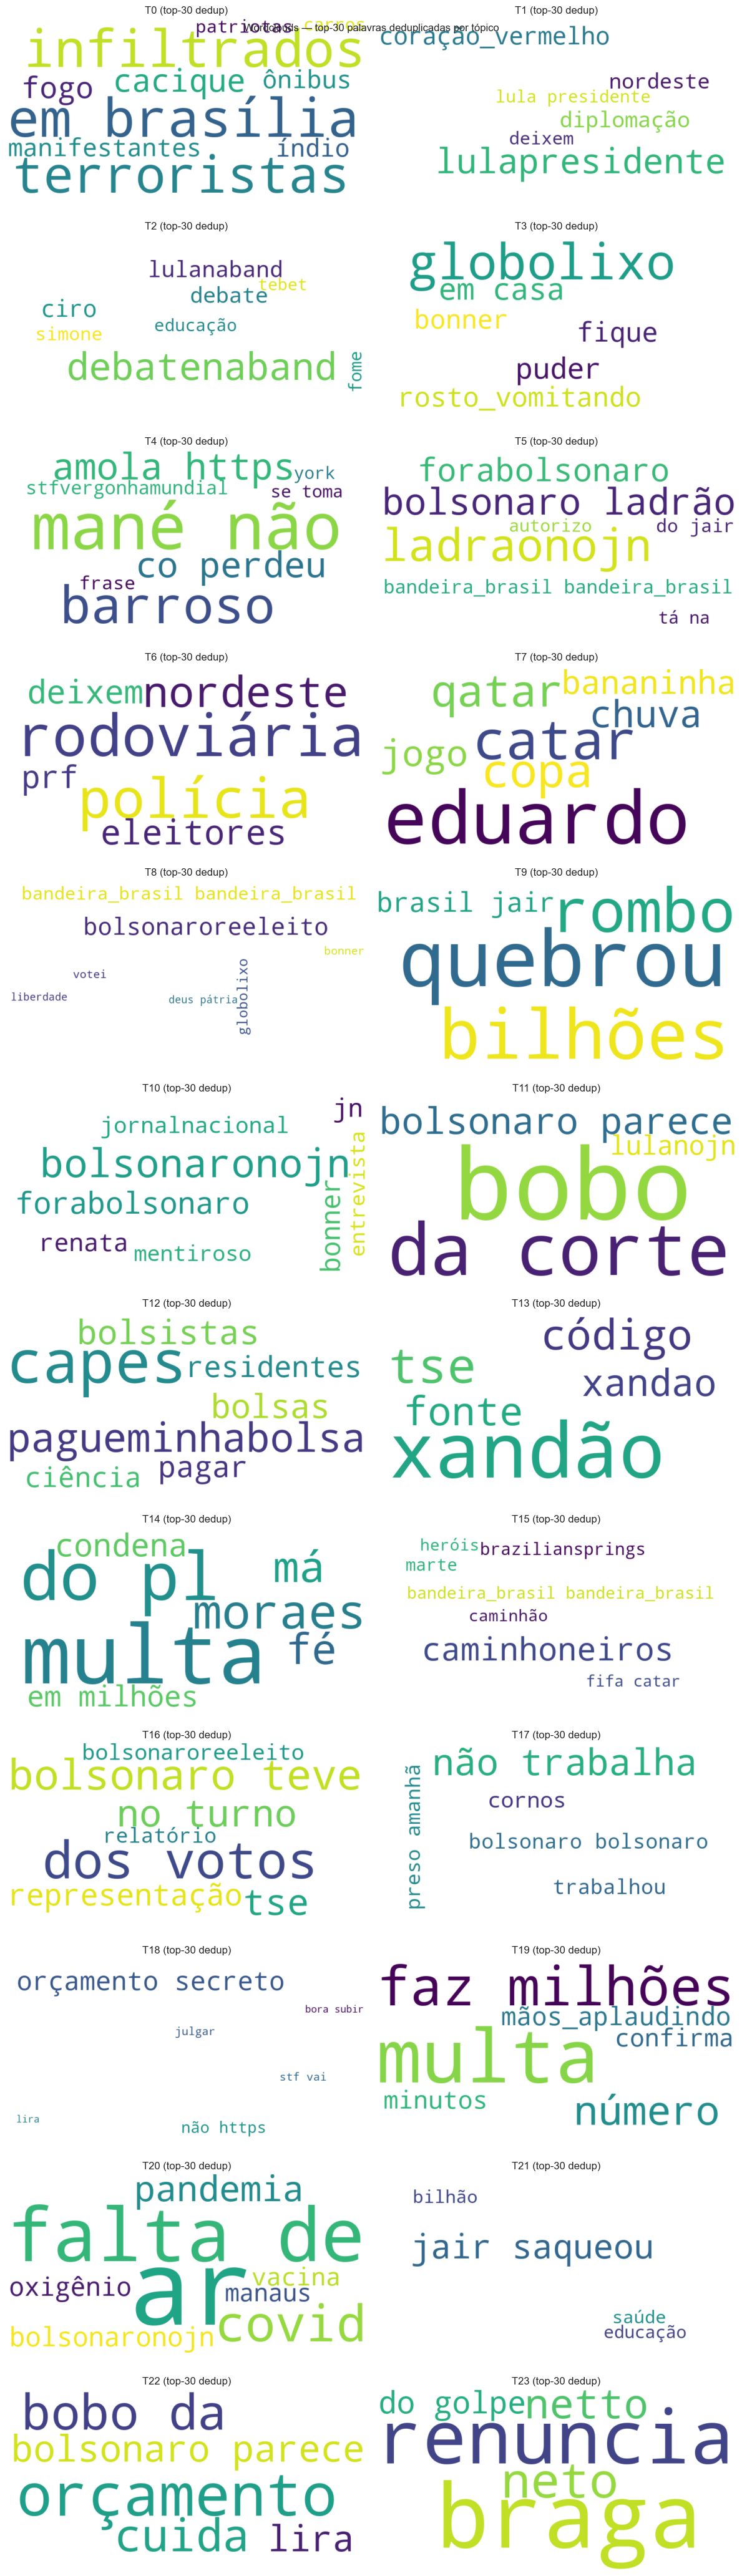

Salvo: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804\bertopic_wordclouds.png


In [12]:
# Cell 10 — Wordclouds (mesmo estilo da Folha: dedupe por raiz, 2 col, viridis, top-30)
N_PALAVRAS = 30


def _shares_root(s1: str, s2: str, max_diff: int = 2) -> bool:
    if s1 == s2:
        return True
    short, long_ = (s1, s2) if len(s1) <= len(s2) else (s2, s1)
    if len(short) < 3:
        return False
    return long_.startswith(short) and (len(long_) - len(short)) <= max_diff


def top_words_deduped(tid, n=N_PALAVRAS, pool=100):
    kws = topic_model.get_topic(tid) or []
    kept, kept_tokens = [], []
    for word, score in kws[:pool]:
        if score <= 0:
            break
        tokens = word.split()
        if any(_shares_root(t, kt) for t in tokens for kt in kept_tokens):
            continue
        kept.append((word, score))
        kept_tokens.extend(tokens)
        if len(kept) >= n:
            break
    return kept


n_topics = len(topics_keywords)
cols = 2
rows = (n_topics + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(12, 3.5 * rows))
axes = np.array(axes).flatten()

for ax, tid in zip(axes, sorted(topics_keywords)):
    words = {w: s for w, s in top_words_deduped(tid) if w and s > 0}
    if len(words) < 2:
        ax.set_title(f"T{tid} (sem palavras válidas)")
        ax.axis("off")
        continue
    wc = WordCloud(
        background_color="white", width=800, height=400,
        colormap="viridis", max_words=N_PALAVRAS,
    ).generate_from_frequencies(words)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"T{tid} (top-{N_PALAVRAS} dedup)")
    ax.axis("off")

for ax in axes[n_topics:]:
    ax.axis("off")

plt.suptitle(f"Wordclouds — top-{N_PALAVRAS} palavras deduplicadas por tópico")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "bertopic_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvo: {RESULTS_DIR / 'bertopic_wordclouds.png'}")

## 6. Rotulagem via LLM (Ollama)

In [13]:
# Cell 11 — Nomeação LLM (pipeline completo: centróide docs + anti-redundância + dedupe)
llm_cfg = params["llm"]
naming_enabled = llm_cfg.get("enabled", True)

FEW_SHOT_EXAMPLES = """Exemplos de bom rótulo (frase nominal coerente):

  Palavras-chave: lula, eleição, presidente, voto, urna, campanha
  Rótulo: Eleições presidenciais e disputa eleitoral

  Palavras-chave: bolsonaro, golpe, militares, manifestantes, acampamento
  Rótulo: Contestação dos resultados eleitorais

  Palavras-chave: stf, supremo, ministro, julgamento, lei, constituição
  Rótulo: Decisões do Supremo Tribunal Federal

  Palavras-chave: fake_news, desinformação, mentira, verificação, rumor
  Rótulo: Desinformação e fake news eleitorais

  Palavras-chave: pesquisa, datafolha, ipec, intenção, voto, eleitor
  Rótulo: Pesquisas eleitorais e intenção de voto

  Palavras-chave: urna, fraude, sistema, eletrônico, auditoria, voto
  Rótulo: Segurança e auditoria do sistema eleitoral

Exemplos de DOIS temas PRÓXIMOS nomeados de forma DISTINTA (faça assim):

  Palavras-chave: lula, petista, petê, eleição, governo, candidato
  Rótulo: Campanha e apoio ao candidato Lula

  Palavras-chave: bolsonarismo, extrema_direita, apoiadores, manifestação, direita
  Rótulo: Movimento bolsonarista e manifestações de apoio

Exemplo de rótulo RUIM (NÃO faça assim):

  - "lula, eleição, voto" (é LISTA de keywords, não rótulo)
"""


def prompt_builder_custom(keywords, example_docs=None, assigned_names=None):
    """Prompt PT-BR com few-shot, anti-redundância e docs centróide.

    keywords : list[str]
        Keywords do tópico (sliceado para top_n_llm do escopo da Cell 9).
    example_docs : list[str] | None
        3 tweets representativos do centróide do cluster.
    assigned_names : list[str] | None
        Nomes já atribuídos — LLM deve ser distinto deles.
    """
    keywords_str = ", ".join(keywords[:top_n_llm])

    avoid_block = ""
    if assigned_names:
        _listed = "\n".join(f"- {n}" for n in assigned_names)
        avoid_block = (
            "\nRÓTULOS já atribuídos a outros tópicos (NÃO repita nem faça variação leve):\n"
            + _listed + "\n"
            + "\nSe este tópico for parecido com algum acima, identifique o termo das "
            "palavras-chave que o DIFERENCIA e use-o no rótulo. NUNCA use sufixos "
            "como '(2)' ou '(gol)'.\n\n"
        )

    docs_block = ""
    if example_docs:
        snippets = []
        for i, d in enumerate(example_docs[:3]):
            text = d if isinstance(d, str) else str(d)
            snippets.append(f"[Tweet {i + 1}]\n{text[:200].strip()}...")
        if snippets:
            docs_block = "\n\nTweets representativos do tópico:\n" + "\n\n".join(snippets)

    return (
        "Você é um especialista em análise temática de tweets políticos brasileiros.\n"
        "Sua tarefa é criar um RÓTULO HUMANO LEGÍVEL para um tópico descoberto "
        "automaticamente (frase nominal em português brasileiro, 4-6 palavras).\n\n"
        + FEW_SHOT_EXAMPLES + "\n"
        + avoid_block
        + "Agora nomeie este tópico:\n\n"
        f"Palavras-chave: {keywords_str}"
        f"{docs_block}\n\n"
        "Regras:\n"
        "- Uma única frase nominal coerente (4-6 palavras).\n"
        "- As PRIMEIRAS palavras-chave são as mais importantes (maior peso): baseie o rótulo nelas.\n"
        "- Se as palavras misturarem dois assuntos, nomeie o ASSUNTO DOMINANTE, não uma mistura vaga.\n"
        "- Nomeie o TEMA GERAL comum aos tweets, não um evento isolado.\n"
        "- Rótulo CLARAMENTE DISTINTO dos já listados (use o termo que diferencia este tópico).\n"
        "- Sem aspas, sem prefixo 'Rótulo:', sem explicações.\n"
        "Rótulo:"
    )


system_prompt_custom = (
    "Você é um especialista em análise temática de tweets políticos brasileiros. "
    "Responda SEMPRE em português brasileiro com uma frase nominal curta (4-6 palavras). "
    "NUNCA use listas de palavras-chave separadas por vírgula."
)

# Sanity check do prompt
if valid_ids:
    _example_keywords = topics_keywords[valid_ids[0]][:top_n_llm]
    print(f"=== Sanity check do prompt para T{valid_ids[0]} ===")
    print(prompt_builder_custom(
        _example_keywords,
        assigned_names=["Eleições presidenciais e disputa eleitoral", "Contestação dos resultados eleitorais"]
    )[:1200])
    print("...")

N_REPR_DOCS = 3   # docs do centróide por tópico (amplitude → menos over-specification)

_docs_src_name = globals().get("docs_raw", docs)
_emb_name = embeddings
_topics_arr = np.array(topics)


def _representative_docs_tweets(tid, n=N_REPR_DOCS):
    """Retorna os n tweets mais próximos do centróide do cluster (embeddings)."""
    idxs = np.where(_topics_arr == tid)[0]
    if len(idxs) == 0:
        return []
    sub = _emb_name[idxs].astype(float)
    cen = sub.mean(axis=0)
    cen = cen / (np.linalg.norm(cen) + 1e-9)
    order = np.argsort(-(sub @ cen))
    return [_docs_src_name[idxs[j]] for j in order[:n]]


def _dedupe_name_tweets(name, keywords, used_lower):
    """Garante unicidade — se colidir, anexa keyword mais distintiva ou sufixo numérico."""
    if name.lower() not in used_lower:
        return name
    for kw in keywords:
        candidate = name + " — " + kw
        if candidate.lower() not in used_lower:
            return candidate
    i = 2
    while (name + f" ({i})").lower() in used_lower:
        i += 1
    return name + f" ({i})"


# Ordenar por tamanho (maiores primeiro → nomes centrais ocupados primeiro)
_topic_counts = {
    tid: int(topic_info[topic_info["Topic"] == tid]["Count"].values[0])
    for tid in valid_ids
}
_order = sorted(valid_ids, key=lambda t: -_topic_counts[t])

_used_lower: set = set()
_assigned_names: list = []
topics_names: dict = {}

if naming_enabled:
    print(f"\nNomeando {len(valid_ids)} tópicos via LLM ({llm_cfg['model']})...")
    print(f"  docs representativos: {N_REPR_DOCS} centróide | anti-redundância: ativo | ordem: maior → menor")

    for tid in _order:
        kws = topics_keywords[tid]
        rep_docs = _representative_docs_tweets(tid)

        def _pb(keywords, example_docs=None, _an=list(_assigned_names)):
            return prompt_builder_custom(keywords, example_docs, assigned_names=_an)

        t0 = time.time()
        name = name_topic(
            kws,
            model=llm_cfg["model"],
            base_url=llm_cfg["base_url"],
            example_docs=rep_docs,
            prompt_builder=_pb,
            system_prompt=system_prompt_custom,
        )
        name = _dedupe_name_tweets(name, kws, _used_lower)
        _used_lower.add(name.lower())
        _assigned_names.append(name)
        topics_names[tid] = name

        top3 = ", ".join(kws[:3])
        print(f"  T{tid:>2} ({_topic_counts[tid]:>4} docs, {time.time() - t0:.1f}s): {name}")
        print(f"       [{top3}]")

else:
    print("Nomeação LLM desabilitada — usando smart fallback.")
    topics_names = {tid: _smart_fallback(kws) for tid, kws in topics_keywords.items()}

# Reordena na ordem natural dos tópicos para downstream estável
topics_names = {t: topics_names[t] for t in valid_ids}
topic_model.set_topic_labels(topics_names)

# Alias retrocompat para células downstream
names = topics_names

# Salvar nomes
names_df = pd.DataFrame([
    {"topic_id": tid, "topic_name": topics_names[tid]}
    for tid in valid_ids
])
names_df.to_csv(RESULTS_DIR / "bertopic_topic_names.csv", index=False)
print(f"\n✓ Salvo: bertopic_topic_names.csv ({len(names_df)} tópicos)")

print()
for tid in sorted(names):
    print(f"  T{tid:2d} [{names[tid]}]: {topics_keywords[tid][:5]}")

=== Sanity check do prompt para T0 ===
Você é um especialista em análise temática de tweets políticos brasileiros.
Sua tarefa é criar um RÓTULO HUMANO LEGÍVEL para um tópico descoberto automaticamente (frase nominal em português brasileiro, 4-6 palavras).

Exemplos de bom rótulo (frase nominal coerente):

  Palavras-chave: lula, eleição, presidente, voto, urna, campanha
  Rótulo: Eleições presidenciais e disputa eleitoral

  Palavras-chave: bolsonaro, golpe, militares, manifestantes, acampamento
  Rótulo: Contestação dos resultados eleitorais

  Palavras-chave: stf, supremo, ministro, julgamento, lei, constituição
  Rótulo: Decisões do Supremo Tribunal Federal

  Palavras-chave: fake_news, desinformação, mentira, verificação, rumor
  Rótulo: Desinformação e fake news eleitorais

  Palavras-chave: pesquisa, datafolha, ipec, intenção, voto, eleitor
  Rótulo: Pesquisas eleitorais e intenção de voto

  Palavras-chave: urna, fraude, sistema, eletrônico, auditoria, voto
  Rótulo: Segurança e

  T 0 (1681 docs, 14.4s): Atos de terrorismo em Brasília
       [em brasília, infiltrados, terroristas]


  T 1 (1208 docs, 7.4s): Eleições e vitória de Lula
       [lulapresidente, lulapresidente https, coração_vermelho]


  T 2 ( 669 docs, 15.3s): Debates e posicionamento político
       [debatenaband, ciro, debatenaband https]


  T 3 ( 541 docs, 29.3s): GloboLixo e ataques ao jornalismo
       [globolixo, globolixo https, em casa]


...

  T19 (  70 docs, 2.9s): Multa e milhões de dinheiro
       [multa, faz milhões, de multa]


  T20 (  63 docs, 2.9s): Bolsonarismo e falta de oxigênio
       [ar, de ar, falta de]


  T21 (  58 docs, 3.0s): Saqueio e desabamento do governo Jair Bolsonaro
       [jair saqueou, saqueou, saqueou brasil]


  T22 (  48 docs, 2.7s): Orçamento secreto e Lula
       [orçamento, bobo da, da corte]


  T23 (  41 docs, 2.9s): Renúncia e golpe militar
       [braga, renuncia, renuncia bolsonaro]

✓ Salvo: bertopic_topic_names.csv (24 tópicos)

  T 0 [Atos de terrorismo em Brasília]: ['em brasília', 'infiltrados', 'terroristas', 'cacique', 'fogo']
  T 1 [Eleições e vitória de Lula]: ['lulapresidente', 'lulapresidente https', 'coração_vermelho', 'diplomação', 'nordeste']
  T 2 [Debates e posicionamento político]: ['debatenaband', 'ciro', 'debatenaband https', 'lulanaband', 'debate']
  T 3 [GloboLixo e ataques ao jornalismo]: ['globolixo', 'globolixo https', 'em casa', 'puder', 'se puder']
  T 4 [Barroso e mané na disputa eleitoral]: ['mané não', 'barroso', 'amola https', 'co perdeu', 'amola perdeu']
  T 5 [Manifestações contra Bolsonaro]: ['ladraonojn', 'bolsonaro ladrão', 'ladrão bolsonaro', 'forabolsonaro', 'bandeira_brasil bandeira_brasil']
  T 6 [Operações da Polícia Rodoviária Federal no Nordeste]: ['rodoviária', 'rodoviária federal', 'polícia rodoviária', 'polícia', 'nordeste']
 

Ranking de exclusividade — alta = keywords distintivas, baixa = sobreposição:
 topic_id                                          topic_name  exclusividade  n_docs
       17                  Bolsonaro e desinformação política       0.975403      83
       23                            Renúncia e golpe militar       0.932728      41
        9                      Rombo e crise fiscal no Brasil       0.878280     282
       15                   Caminhoneiros e greve de protesto       0.874022      98
       21     Saqueio e desabamento do governo Jair Bolsonaro       0.866958      58
       12                     Bolsistas e pagamentos da Capes       0.853205     153
        7                   Bolsonaro no Catar e patriotários       0.843998     381
        4                 Barroso e mané na disputa eleitoral       0.837593     433
       20                    Bolsonarismo e falta de oxigênio       0.806839      63
       14                         Multa e condenação política       0.80

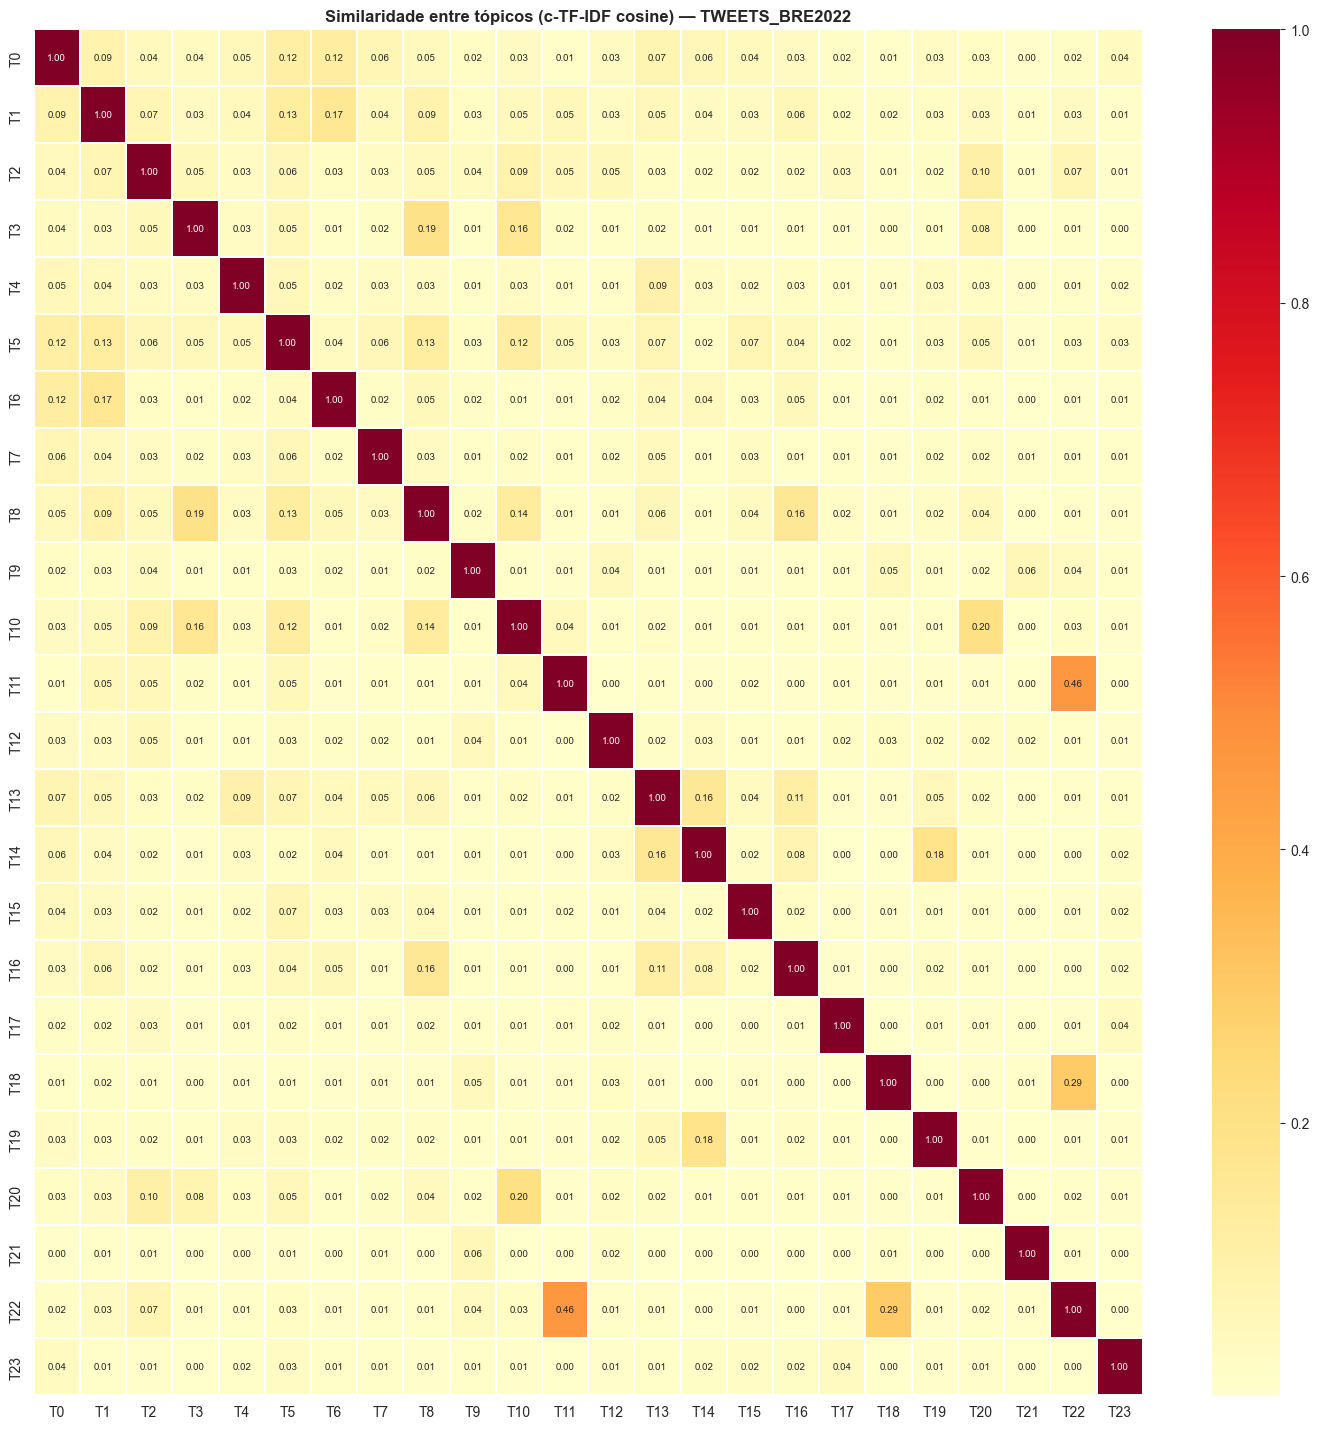

✓ Salvo: bertopic_heatmap_topicos_cosine.png

Top-5 pares de tópicos mais similares (potenciais merge candidates):
  T11 (Bolsonarismo e ataques a Lula) ↔ T22 (Orçamento secreto e Lula)  sim=0.464
  T18 (Orçamento secreto e transparên) ↔ T22 (Orçamento secreto e Lula)  sim=0.294
  T10 (Bolsonaristas e ataques ao jor) ↔ T20 (Bolsonarismo e falta de oxigên)  sim=0.204
  T 3 (GloboLixo e ataques ao jornali) ↔ T 8 (Bolsonarismo e eleições 2022)  sim=0.193
  T14 (Multa e condenação política) ↔ T19 (Multa e milhões de dinheiro)  sim=0.184


In [14]:
# Exclusividade ranking + heatmap cosine similarity entre tópicos
from sklearn.metrics.pairwise import cosine_similarity

excl_df = pd.DataFrame([
    {
        "topic_id": tid,
        "topic_name": topics_names.get(tid, _fallback_label(topics_keywords.get(tid, []))),
        "exclusividade": excl_per_topic[tid],
        "n_docs": int(topic_info[topic_info["Topic"] == tid]["Count"].values[0]),
    }
    for tid in valid_ids
]).sort_values("exclusividade", ascending=False).reset_index(drop=True)

print("Ranking de exclusividade — alta = keywords distintivas, baixa = sobreposição:")
print(excl_df.to_string(index=False))
excl_df.to_csv(RESULTS_DIR / "bertopic_exclusividade_ranking.csv", index=False)
print(f"\n✓ Salvo: bertopic_exclusividade_ranking.csv")

# Heatmap cosine similarity c-TF-IDF
_all_tids_sim  = sorted(topic_model.get_topics().keys())
_tid_to_row_sim = {t: i for i, t in enumerate(_all_tids_sim)}
topic_vecs = np.array([topic_model.c_tf_idf_.toarray()[_tid_to_row_sim[t]] for t in valid_ids])

sim_matrix = cosine_similarity(topic_vecs)
short_labels = [f"T{t}" for t in valid_ids]

fig, ax = plt.subplots(figsize=(max(8, 0.6 * len(valid_ids)), max(7, 0.6 * len(valid_ids))))
sns.heatmap(
    sim_matrix, annot=True, fmt=".2f", cmap="YlOrRd",
    xticklabels=short_labels, yticklabels=short_labels,
    linewidths=0.3, ax=ax, annot_kws={"fontsize": 7},
)
ax.set_title(f"Similaridade entre tópicos (c-TF-IDF cosine) — {CORPUS_ID.upper()}",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "bertopic_heatmap_topicos_cosine.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"✓ Salvo: bertopic_heatmap_topicos_cosine.png")

# Top-5 pares mais similares (potenciais merge candidates)
n_tv = len(valid_ids)
pairs_sim = []
for _i in range(n_tv):
    for _j in range(_i + 1, n_tv):
        pairs_sim.append((valid_ids[_i], valid_ids[_j], float(sim_matrix[_i, _j])))
pairs_sim.sort(key=lambda x: -x[2])
print("\nTop-5 pares de tópicos mais similares (potenciais merge candidates):")
for ta, tb, sim_val in pairs_sim[:5]:
    na = topics_names.get(ta, f"T{ta}")[:30]
    nb = topics_names.get(tb, f"T{tb}")[:30]
    print(f"  T{ta:2d} ({na}) ↔ T{tb:2d} ({nb})  sim={sim_val:.3f}")

## 7. Métricas quantitativas

Tokenizando corpus para C_v (sample 5k)...


Calculando C_v...


  [C_v] NAO REPORTADO: 100.0% dos documentos tem menos de 110 tokens (mediana 9). A janela deslizante degenera e o valor deixa de ser o C_v de Roder et al. Valor bruto = 0.6919; use o NPMI.


NPMI (top-20): +0.1869  |  regime C_v: DEGENERADO - nao publicar sob o rotulo C_v

K = 24 tópicos
Outlier rate:             10.6%
Cobertura:                89.4%
Topic Diversity (Dieng):  0.9000
Coerência C_v (Röder):    0.6919
Coerência Semântica:      0.6697
Exclusividade c-TF-IDF:   0.7397
FREX médio:               0.9830


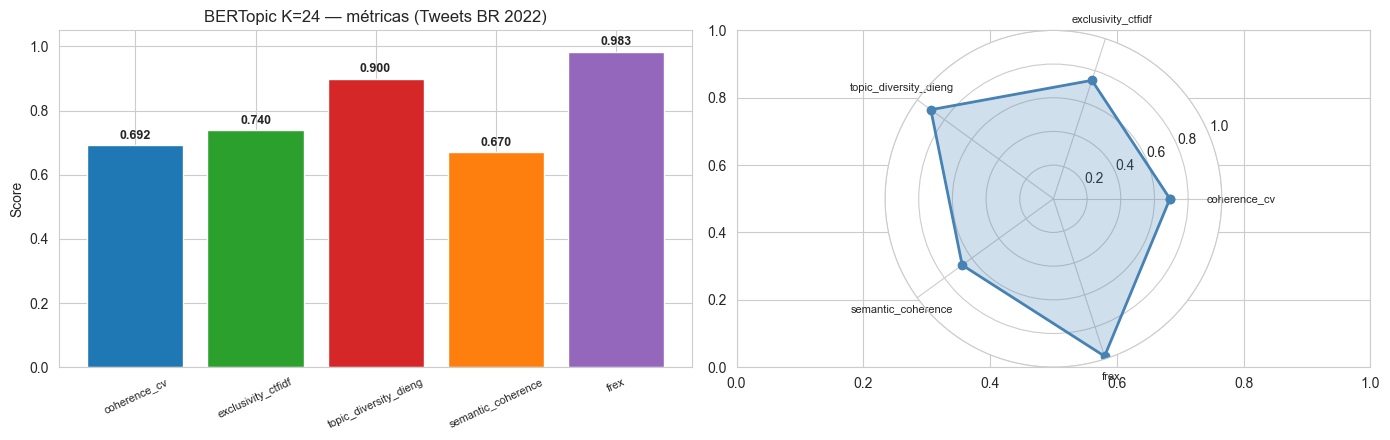

{
  "model": "bertopic",
  "topic_type": "semantic",
  "granularity": "unit",
  "corpus": "tweets_bre2022",
  "n_topics": 24,
  "outlier_rate": 0.10566337532629667,
  "coverage": 0.8943366246737033,
  "exclusivity": 0.7397053367927932,
  "exclusivity_simple": 0.8981481481481481,
  "exclusivity_ctfidf": 0.7397053367927932,
  "topic_diversity_dieng": 0.9,
  "coherence_cv": 0.6918945927789423,
  "coherence_npmi": 0.18691172214657173,
  "cv_regime_ok": false,
  "metrics_top_n": 20,
  "oov_taxa": 0.5625,
  "n_topicos_descartados_coerencia": 0,
  "semantic_coherence": 0.669715918628154,
  "frex": 0.9829760310287526
}


In [15]:
# Cell 12 — Métricas quantitativas completas
from _helpers import lemmatize_corpus

print("Tokenizando corpus para C_v (sample 5k)...")
sample_idx = np.random.RandomState(42).choice(len(docs), min(5000, len(docs)), replace=False)
docs_sample = [docs[i] for i in sample_idx]
try:
    tokenized, dictionary = lemmatize_corpus(docs_sample, "pt", params)
except Exception as e:
    print(f"  lemmatize_corpus falhou ({e}) — tokenização simples como fallback")
    tokenized = [d.lower().split() for d in docs_sample]
    from gensim.corpora import Dictionary as _Dict
    dictionary = _Dict(tokenized)

print("Calculando C_v...")
try:
    cv_score = float(compute_coherence_cv(topics_keywords_ctfidf, tokenized, dictionary))
except Exception as e:
    print(f"   c_v skipped: {e}")
    cv_score = None

# --- ADICAO 2026-08-16 (protocolo de selecao, docs/protocolo-selecao-final-2026-08-16.md).
#     NPMI passa a ser a coerencia que DECIDE; o C_v vira reporte condicionado ao regime
#     de janela (secao 3.0) e o filtro de OOV passa a ser quantificado. Aditivo: nenhum
#     valor preexistente muda. compute_metrics_table e o MESMO codigo chamado pelo
#     _metricas_pos_hoc.py, que preenche os runs ja existentes sem re-executar nada.
_tab = compute_metrics_table(topics_keywords_ctfidf, tokenized, dictionary, top_n=top_n_metrics)
# NOTA: cv_score acima e calculado sobre topics_keywords SEM fatiar, enquanto
# compute_metrics_table fatia em top_n_metrics. Comparar os dois seria comparar
# bases diferentes; a conferencia usa a MESMA base de proposito.
_cv_ref = float(compute_coherence_cv(
    {t: k[:top_n_metrics] for t, k in topics_keywords_ctfidf.items()}, tokenized, dictionary))
assert abs(_tab["cv_bruto"] - _cv_ref) < 1e-9, (
    "compute_metrics_table divergiu do calculo direto de C_v - investigar antes de publicar"
)
npmi_score = _tab["npmi"]
cv_regime_ok = not _tab["cv_window_degenerado"]
_regime = "OK" if cv_regime_ok else "DEGENERADO - nao publicar sob o rotulo C_v"
print("NPMI (top-%d): %+.4f  |  regime C_v: %s" % (top_n_metrics, npmi_score, _regime))

td = compute_topic_diversity(topics_keywords_ctfidf)

metrics = {
    "model": "bertopic", "topic_type": "semantic", "granularity": "unit",
    "corpus": CORPUS_ID, "n_topics": K, "outlier_rate": float(outlier_rate),
    "coverage": float(coverage),
    # exclusivity: alias retrocompat (c-TF-IDF) + versão simples
    "exclusivity": float(mean_excl_ctfidf),
    "exclusivity_simple": float(compute_exclusivity(topics_keywords_ctfidf)),
    "exclusivity_ctfidf": float(mean_excl_ctfidf),
    "topic_diversity_dieng": float(td),
    "coherence_cv": cv_score,
    "coherence_npmi": float(npmi_score),
    "cv_regime_ok": bool(cv_regime_ok),
    "metrics_top_n": int(top_n_metrics),
    "oov_taxa": float(_tab["oov_taxa"]),
    "n_topicos_descartados_coerencia": int(_tab["n_topicos_descartados"]),
    "semantic_coherence": float(sem_coh),
    "frex": float(mean_frex),
}

print(f"\nK = {K} tópicos")
print(f"Outlier rate:             {outlier_rate:.1%}")
print(f"Cobertura:                {coverage:.1%}")
print(f"Topic Diversity (Dieng):  {td:.4f}")
if cv_score is not None:
    print(f"Coerência C_v (Röder):    {cv_score:.4f}")
print(f"Coerência Semântica:      {sem_coh:.4f}")
print(f"Exclusividade c-TF-IDF:   {mean_excl_ctfidf:.4f}")
print(f"FREX médio:               {mean_frex:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
keys_vis = ["coherence_cv", "exclusivity_ctfidf", "topic_diversity_dieng", "semantic_coherence", "frex"]
vals_vis = [metrics.get(k) or 0 for k in keys_vis]
colors   = ["#1f77b4", "#2ca02c", "#d62728", "#ff7f0e", "#9467bd"]

axes[0].bar(keys_vis, vals_vis, color=colors)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Score")
axes[0].set_title(f"BERTopic K={K} — métricas (Tweets BR 2022)")
axes[0].tick_params(axis="x", rotation=25, labelsize=8)
for i, v in enumerate(vals_vis):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9, fontweight="bold")

angles   = np.linspace(0, 2*np.pi, len(keys_vis), endpoint=False).tolist()
vals_p   = vals_vis + [vals_vis[0]]
angles_p = angles + [angles[0]]
ax_polar = plt.subplot(122, projection="polar")
ax_polar.plot(angles_p, vals_p, "o-", linewidth=2, color="steelblue")
ax_polar.fill(angles_p, vals_p, alpha=0.25, color="steelblue")
ax_polar.set_xticks(angles); ax_polar.set_xticklabels(keys_vis, fontsize=8); ax_polar.set_ylim(0, 1)
plt.tight_layout(); plt.show()

print(json.dumps(metrics, indent=2, default=str))

## Sweep de estrategias/threshold de reduce_outliers + grid UMAP/HDBSCAN

Usa `_helpers.sweep_outlier_strategies` / `sweep_outlier_threshold` /
`sweep_bertopic_grid` para comparar empiricamente, via multiplos seeds,
alternativas ao pipeline fixo acima (pos-processamento em 4 etapas com a estrategia/nn/mcs do
`params.yaml`). Metricas: C_v, Topic Diversity, Exclusividade c-TF-IDF, FREX
e estabilidade Jaccard multi-seed.

> **Custoso** (refit completo por combinacao x seed). Habilitar via
> `evaluation.run_outlier_sweep` / `evaluation.run_param_sweep` no
> `params.yaml`. Por padrao ambos sao pulados.


In [16]:
eval_cfg = params["evaluation"]
top_n_sweep_metrics = eval_cfg.get("top_n_keywords_metrics", 20)
from _helpers import sweep_outlier_strategies, sweep_outlier_threshold, sweep_bertopic_grid


def _sweep_vectorizer():
    """Vectorizer FRESCO por modelo do sweep — update_topics re-fita o
    vectorizer in-place; reusar a instancia global `vectorizer` corromperia
    seu vocab entre variantes."""
    return CountVectorizer(
        ngram_range=tuple(vec_params["ngram_range"]),
        token_pattern=cfg.get("token_pattern", r"(?u)\b[a-zA-ZÀ-ÿ_]{2,}\b"),
        max_df=0.5,
    )


def _sweep_build_model(seed, n_neighbors=None, min_cluster_size=None, min_samples=None, cluster_selection_method=None):
    nn = n_neighbors if n_neighbors is not None else umap_params["n_neighbors"]
    mcs = min_cluster_size if min_cluster_size is not None else hdbscan_params["min_cluster_size"]
    ms = min_samples if min_samples is not None else hdbscan_params["min_samples"]
    csm = cluster_selection_method if cluster_selection_method is not None else hdbscan_params.get("cluster_selection_method", "leaf")
    umap_s = UMAP(
        n_components=umap_params["n_components"], n_neighbors=nn,
        min_dist=umap_params["min_dist"], metric=umap_params["metric"],
        random_state=seed,
    )
    hdb_s = HDBSCAN(
        min_cluster_size=mcs, min_samples=ms,
        cluster_selection_method=csm,
        prediction_data=True,
    )
    return BERTopic(
        embedding_model=None, umap_model=umap_s, hdbscan_model=hdb_s,
        vectorizer_model=_sweep_vectorizer(),
        representation_model={"MMR": MaximalMarginalRelevance(diversity=bert_cfg["mmr_diversity"], top_n_words=top_n_cache)},
        min_topic_size=bert_cfg["min_topic_size"], language=cfg.get("bertopic_language", "multilingual"),
        calculate_probabilities=True, verbose=False,
    )


if eval_cfg.get("run_outlier_sweep", False):
    sweep_seeds = eval_cfg.get("outlier_sweep_seeds", [42, 123, 456, 789, 1024])
    sweep_strategies = eval_cfg.get(
        "outlier_sweep_strategies",
        ["off", "c-tf-idf", "embeddings", "probabilities", "distributions"],
    )
    print(f"Sweep de estrategias ({len(sweep_strategies)} estrategias x {len(sweep_seeds)} seeds)...")
    raw_strat, agg_strat = sweep_outlier_strategies(
        lambda s: _sweep_build_model(s), docs, embeddings, tokenized, dictionary,
        sweep_seeds, strategies=sweep_strategies,
        reduce_nr=bert_cfg.get("reduce_topics_nr", 30), top_n_metrics=top_n_sweep_metrics,
        checkpoint_path=RESULTS_DIR / "sweep_outlier_strategies_checkpoint.csv",
    )
    raw_strat.to_csv(RESULTS_DIR / "sweep_outlier_strategies_raw.csv", index=False)
    agg_strat.to_csv(RESULTS_DIR / "sweep_outlier_strategies.csv", index=False)
    print(agg_strat.to_string(index=False))
else:
    print("Sweep de estrategias desabilitado (evaluation.run_outlier_sweep=false).")
    agg_strat = pd.DataFrame()

if eval_cfg.get("run_threshold_sweep", False):
    thr_seeds = eval_cfg.get("threshold_sweep_seeds", [42])
    thr_grids = eval_cfg.get("threshold_sweep_grids", {})
    if thr_grids:
        n_pts = sum(len(v) for v in thr_grids.values())
        print(f"Sweep de threshold ({len(thr_grids)} estrategias x {n_pts} pontos x {len(thr_seeds)} seeds)...")
        raw_thr, agg_thr = sweep_outlier_threshold(
            lambda s: _sweep_build_model(s), docs, embeddings, tokenized, dictionary,
            thr_seeds, grids=thr_grids,
            reduce_nr=bert_cfg.get("reduce_topics_nr", 30), top_n_metrics=top_n_sweep_metrics,
            checkpoint_path=RESULTS_DIR / "sweep_outlier_threshold_checkpoint.csv",
        )
        raw_thr.to_csv(RESULTS_DIR / "sweep_outlier_threshold_raw.csv", index=False)
        agg_thr.to_csv(RESULTS_DIR / "sweep_outlier_threshold.csv", index=False)
        print(agg_thr.to_string(index=False))
    else:
        print("threshold_sweep_grids vazio — nada a varrer.")
else:
    print("Sweep de threshold desabilitado (evaluation.run_threshold_sweep=false).")
    agg_thr = pd.DataFrame()

if eval_cfg.get("run_param_sweep", False):
    grid_seeds = eval_cfg.get("param_sweep_seeds", [42, 123, 456])
    nn_grid = eval_cfg.get("param_sweep_n_neighbors", [umap_params["n_neighbors"]])
    mcs_grid = eval_cfg.get("param_sweep_min_cluster_size", [hdbscan_params["min_cluster_size"]])
    ms_grid = eval_cfg.get("param_sweep_min_samples", [None])  # [None] = usa o min_samples padrao do corpus
    csm_grid = eval_cfg.get("param_sweep_cluster_selection_methods", ["leaf"])
    print(f"Grid UMAP/HDBSCAN ({len(nn_grid)} nn x {len(mcs_grid)} mcs x {len(ms_grid)} ms x {len(csm_grid)} csm x {len(grid_seeds)} seeds)...")
    raw_grid, agg_grid = sweep_bertopic_grid(
        _sweep_build_model, docs, embeddings, tokenized, dictionary, grid_seeds,
        n_neighbors_grid=nn_grid, min_cluster_size_grid=mcs_grid, min_samples_grid=ms_grid,
        cluster_selection_methods_grid=csm_grid,
        reduce_nr_grid=eval_cfg.get("param_sweep_reduce_topics_nr", [bert_cfg.get("reduce_topics_nr", 30)]),
        outlier_strategy="off",  # sempre off no grid: isola efeito estrutural
        top_n_metrics=top_n_sweep_metrics,
        checkpoint_path=RESULTS_DIR / "sweep_bertopic_grid_checkpoint.csv",
    )
    raw_grid.to_csv(RESULTS_DIR / "sweep_bertopic_grid_raw.csv", index=False)
    agg_grid.to_csv(RESULTS_DIR / "sweep_bertopic_grid.csv", index=False)
    print(agg_grid.to_string(index=False))
else:
    print("Grid UMAP/HDBSCAN desabilitado (evaluation.run_param_sweep=false).")
    agg_grid = pd.DataFrame()


Sweep de estrategias desabilitado (evaluation.run_outlier_sweep=false).
Sweep de threshold desabilitado (evaluation.run_threshold_sweep=false).
Grid UMAP/HDBSCAN desabilitado (evaluation.run_param_sweep=false).


## 8. Validação temporal — tópico × mês eleitoral

A distribuição dos tópicos por mês permite validar se BERTopic captura as fases eleitorais conhecidas.

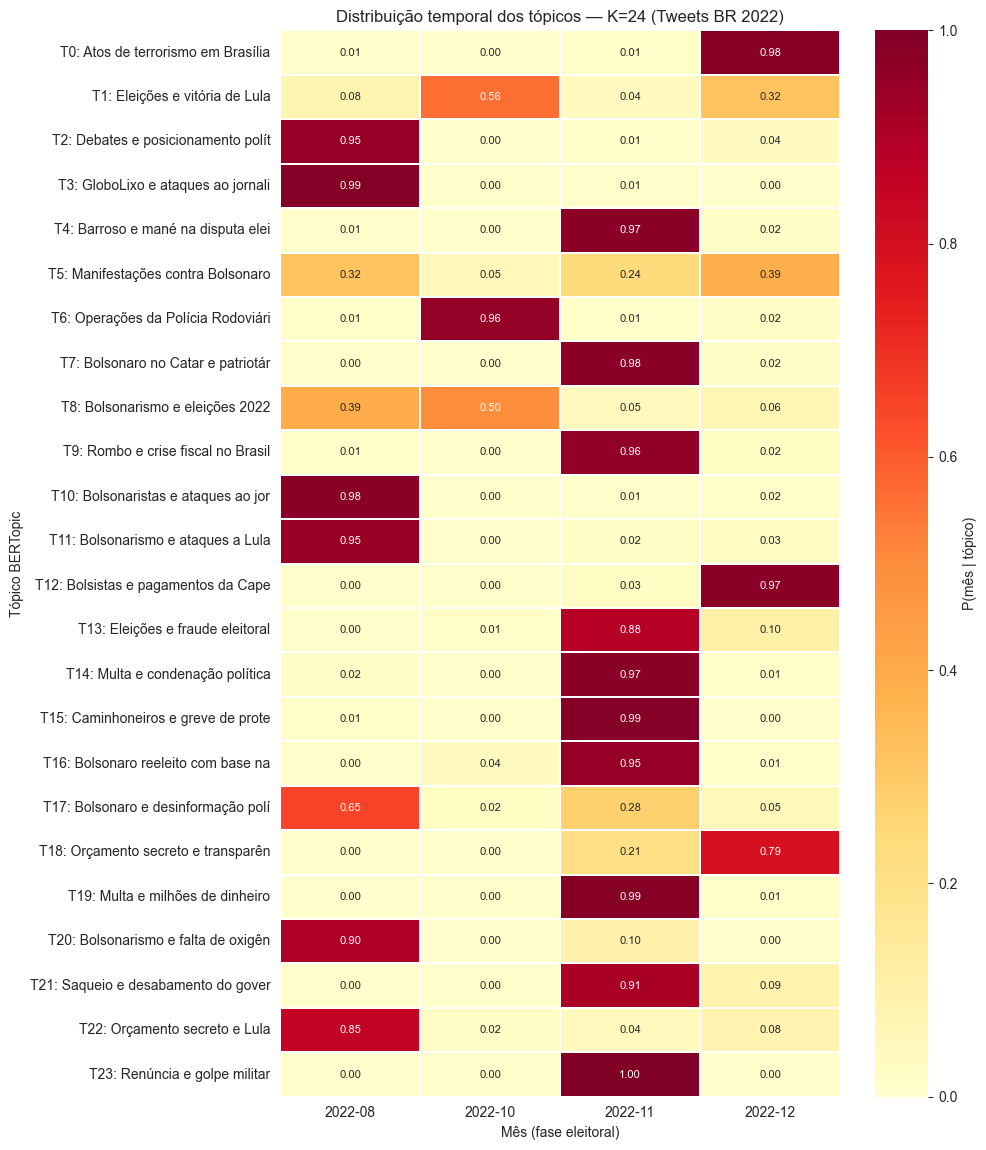

Tópicos com >=50% dos docs num único mês: 22/24


In [17]:
# Cell 13 — Heatmap topic × mês
df_topic = df[["category"]].copy()
df_topic["topic_id"] = topics
df_topic = df_topic[df_topic["topic_id"] != -1]

ct = pd.crosstab(df_topic["topic_id"], df_topic["category"], normalize="index")
ct.index = [f"T{i}: {names.get(i, '')[:30]}" for i in ct.index]

fig, ax = plt.subplots(figsize=(10, 0.4 * len(ct) + 2))
sns.heatmap(ct, annot=True, fmt=".2f", cmap="YlOrRd",
            cbar_kws={"label": "P(mês | tópico)"},
            linewidths=0.3, ax=ax, annot_kws={"fontsize": 8})
ax.set_xlabel("Mês (fase eleitoral)")
ax.set_ylabel("Tópico BERTopic")
ax.set_title(f"Distribuição temporal dos tópicos — K={K} (Tweets BR 2022)")
plt.tight_layout(); plt.show()

# Tópicos concentrados num único mês (dominância >= 0.5)
dominant_month = ct.idxmax(axis=1)
dominant_pct = ct.max(axis=1)
n_concentrated = (dominant_pct >= 0.5).sum()
print(f"Tópicos com >=50% dos docs num único mês: {n_concentrated}/{K}")

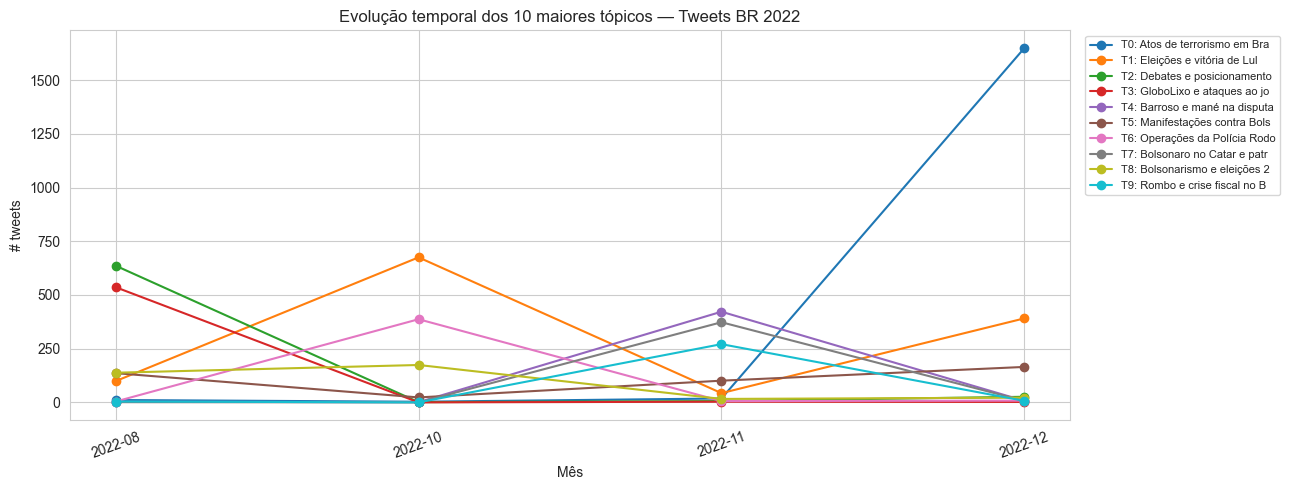

In [18]:
# Cell 14 — Evolução temporal: volume por tópico ao longo dos meses
df_ev = df_topic.copy()
df_ev["month"] = df_ev["category"]

# Seleciona top-10 tópicos por volume total
top_topics = df_topic["topic_id"].value_counts().head(10).index.tolist()

pivot = df_ev[df_ev["topic_id"].isin(top_topics)].groupby(
    ["month", "topic_id"]
).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(13, 5))
for tid in pivot.columns:
    label = f"T{tid}: {names.get(tid, '')[:25]}"
    ax.plot(pivot.index, pivot[tid], marker="o", label=label, linewidth=1.5)
ax.set_xlabel("Mês"); ax.set_ylabel("# tweets")
ax.set_title("Evolução temporal dos 10 maiores tópicos — Tweets BR 2022")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

## 9. UMAP 2D — espaço latente

UMAP 2D (sample 10k)...


  18s


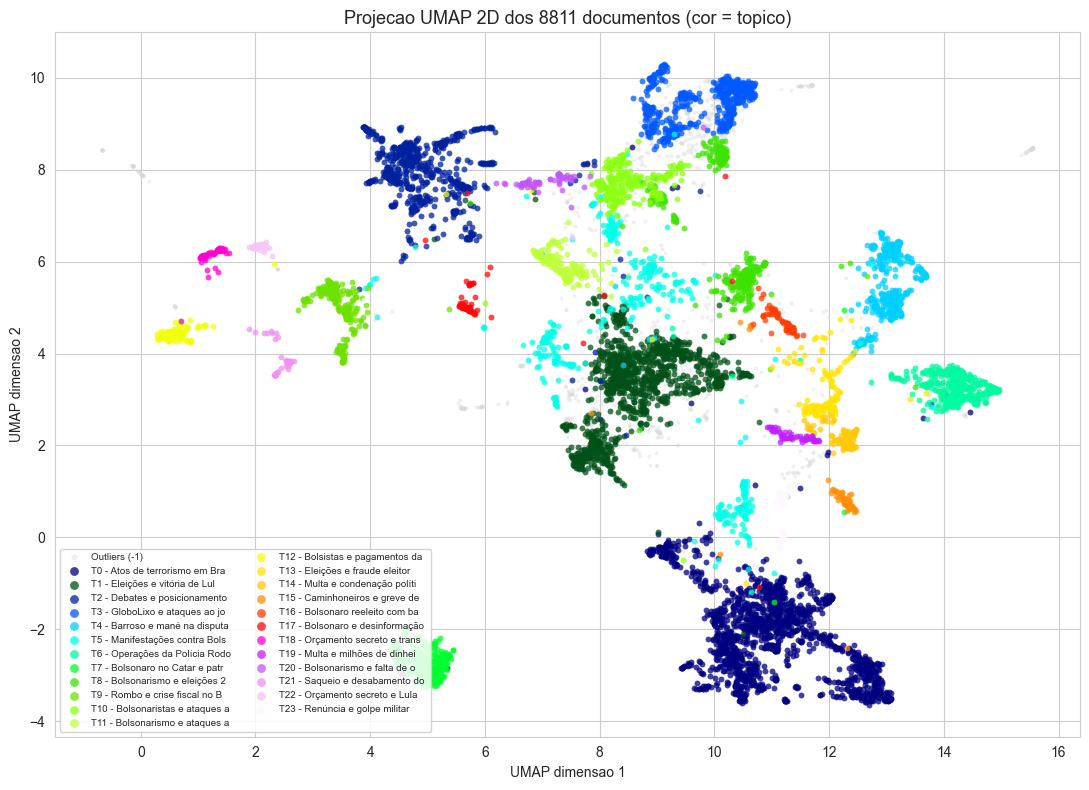

Salvo: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804\bertopic_umap_documents_static.png


In [19]:
# Cell 15 — UMAP 2D scatter (mesmo estilo da Folha: legenda discreta por tópico nomeado)
print("UMAP 2D (sample 10k)...")
sample_n = min(10000, len(docs))
sample_idx = np.random.RandomState(42).choice(len(docs), sample_n, replace=False)
emb_sample = embeddings[sample_idx]
topics_sample = np.array(topics)[sample_idx]

t0 = time.time()
n_neighbors_eff_v6 = min(15, max(2, sample_n - 1))
umap_2d = UMAP(n_components=2, n_neighbors=n_neighbors_eff_v6, min_dist=0.1, metric="cosine", random_state=seed)
xy = umap_2d.fit_transform(emb_sample)
print(f"  {time.time()-t0:.0f}s")

unique_topics = sorted(set(topics_sample.tolist()))
valid_ids_plot = [t for t in unique_topics if t != -1]
n_valid = len(valid_ids_plot)

cmap = plt.get_cmap("tab20" if n_valid <= 20 else "gist_ncar", max(n_valid, 1))
color_map_v6 = {t: cmap(i) for i, t in enumerate(valid_ids_plot)}
color_map_v6[-1] = (0.85, 0.85, 0.85, 0.6)  # outliers em cinza claro


def _legend_label(tid):
    if tid == -1:
        return "Outliers (-1)"
    name = topics_names.get(tid, "")[:25]
    return f"T{tid}" + (f" - {name}" if name else "")


fig, ax = plt.subplots(figsize=(11, 8))

mask_out = topics_sample == -1
if mask_out.any():
    ax.scatter(
        xy[mask_out, 0], xy[mask_out, 1],
        c=[color_map_v6[-1]], s=8, alpha=0.4, linewidths=0,
        label=_legend_label(-1),
    )

for tid in valid_ids_plot:
    mask = topics_sample == tid
    ax.scatter(
        xy[mask, 0], xy[mask, 1],
        c=[color_map_v6[tid]], s=18, alpha=0.75, linewidths=0,
        label=_legend_label(tid),
    )

ax.set_title(f"Projecao UMAP 2D dos {sample_n} documentos (cor = topico)", fontsize=13)
ax.set_xlabel("UMAP dimensao 1")
ax.set_ylabel("UMAP dimensao 2")
ax.legend(loc="best", fontsize=7, markerscale=1.5, framealpha=0.85, ncol=2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "bertopic_umap_documents_static.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvo: {RESULTS_DIR / 'bertopic_umap_documents_static.png'}")

## 10. Tweets representativos por tópico

In [20]:
# Cell 16 — Representative docs
TOP_N_DOCS = 3
TRUNC = 250

rep_docs = topic_model.get_representative_docs() if hasattr(topic_model, 'get_representative_docs') else {}

for tid in sorted(topics_keywords)[:10]:
    print(f"=== T{tid} [{names[tid]}] ===")
    print(f"  keywords: {topics_keywords[tid][:8]}\n")
    docs_for_tid = rep_docs.get(tid, [])[:TOP_N_DOCS] if rep_docs else []
    if not docs_for_tid:
        idx_for_tid = [i for i, t in enumerate(topics) if t == tid][:TOP_N_DOCS]
        docs_for_tid = [docs[i] for i in idx_for_tid]
    for rank, text in enumerate(docs_for_tid, 1):
        text_short = text[:TRUNC].replace("\n", " ")
        print(f"  #{rank}: {text_short}...")
    print()

=== T0 [Atos de terrorismo em Brasília] ===
  keywords: ['em brasília', 'infiltrados', 'terroristas', 'cacique', 'fogo', 'manifestantes', 'índio', 'ônibus']

  #1: Agora em Brasília 12/12/2022 Após a prisão do Cacique https://t.co/pk2VPSVX1N...
  #2: @realpfigueiredo Infiltrados e esquerdistas botando fogo em Brasília para culpar os manifestantes patriotas !! https://t.co/i3DoGeSE3O...
  #3: :bandeira_brasil: ATENÇÃO: Após tentar invadir a sede da Polícia Federal, bolsonaristas colocam fogo em ÔNIBUS em Brasília. https://t.co/2ljPdEuk7q...

=== T1 [Eleições e vitória de Lula] ===
  keywords: ['lulapresidente', 'lulapresidente https', 'coração_vermelho', 'diplomação', 'nordeste', 'deixem', 'nordeste votar', 'deixem nordeste']

  #1: @AndreJanonesAdv JÁ VIRAMOS DITADURA ? DEIXEM O NORDESTE VOTAR DEIXEM O NORDESTE VOTAR DEIXEM O NORDESTE VOTAR DEIXEM O NORDESTE VOTAR DEIXEM O NORDESTE VOTAR DEIXEM O NORDESTE VOTAR DEIXEM O NORDESTE VOTAR DEIXEM O NORDESTE VOTAR #LulaPresidente:tec...
  #2

## Visualizações nativas (Plotly interativo)

Três visualizações complementares geradas pelo próprio BERTopic:

| Visualização | Pergunta que responde |
|---|---|
| `visualize_barchart` | *Do que cada tópico fala?* |
| `visualize_topics` | *Como os tópicos se relacionam?* (mapa 2D) |
| `visualize_hierarchy` | *Quais tópicos são candidatos a fusão?* |

Salvas em `data/output/*.html` para consulta offline.


In [21]:
if len(topics_keywords) >= 2:
    fig_bar = topic_model.visualize_barchart(
        top_n_topics=min(10, len(topics_keywords)), n_words=15
    )
    fig_bar.write_html(RESULTS_DIR / "bertopic_barchart.html")
    display(fig_bar)
else:
    print("Poucos tópicos para barchart.")


In [22]:
if len(topics_keywords) >= 2:
    fig_map = topic_model.visualize_topics()
    fig_map.write_html(RESULTS_DIR / "bertopic_topic_map.html")
    display(fig_map)


In [23]:
# Hierarquia rica via hierarchical_topics()
if len(topics_keywords) >= 2:
    try:
        hier = topic_model.hierarchical_topics(docs)
        fig_hier = topic_model.visualize_hierarchy(hierarchical_topics=hier)
        fig_hier.write_html(RESULTS_DIR / "bertopic_hierarchy.html")
        display(fig_hier)
    except Exception as e:
        print(f"Hierarchy skipped: {type(e).__name__}: {e}")


  0%|          | 0/23 [00:00<?, ?it/s]

 91%|█████████▏| 21/23 [00:00<00:00, 199.93it/s]

100%|██████████| 23/23 [00:00<00:00, 179.43it/s]

## R4 — Hierarquia macro: K=8 mega-temas (camada de apresentação)

Usa o `hierarchical_topics()` já calculado para **cortar a árvore em K=8
clusters macro**, sem reprocessar o BERTopic. Cada um dos 29 micro-tópicos
é mapeado a um dos 8 macro-temas.

Vantagens (recomendadas pelo NLP review):
- **Granularidade dupla** preservada: 29 micro + 8 macro
- **Resolve fragmentação**: temas de gênero (T1+T18+T25+T28) podem cair no
  mesmo macro-tema "Mulheres & Gênero"
- **Apresentação para a banca**: visão executiva de "8 grandes agendas" +
  detalhe operacional de "29 sub-tópicos"
- **Custo zero**: a hierarquia já está computada (cell anterior); só fazemos
  agglomerative clustering nos topic embeddings com K=8

Salva `bertopic_macro_temas.csv` (mapping micro→macro) e gera tree-plot
estático em `bertopic_arvore_macro.png`.


=== Macro-temas (K fixo via params.yaml) ===
K macro-temas: 10

Macro-tema 1 (1722 docs, 2 sub-topicos)
   Keywords agregadas: em brasília, infiltrados, braga, renuncia
     T 0 (1681 docs)  Atos de terrorismo em Brasília
     T23 (  41 docs)  Renúncia e golpe militar

Macro-tema 2 (503 docs, 2 sub-topicos)
   Keywords agregadas: rodoviária, rodoviária federal, caminhoneiros, caminhoneiros https
     T 6 ( 405 docs)  Operações da Polícia Rodoviária Federal no Nordest
     T15 (  98 docs)  Caminhoneiros e greve de protesto

Macro-tema 3 (791 docs, 4 sub-topicos)
   Keywords agregadas: eduardo, eduardo bolsonaro, bolsonaronojn, forabolsonaro, não trabalha
     T 7 ( 381 docs)  Bolsonaro no Catar e patriotários
     T10 ( 264 docs)  Bolsonaristas e ataques ao jornal
     T17 (  83 docs)  Bolsonaro e desinformação política
     T20 (  63 docs)  Bolsonarismo e falta de oxigênio

Macro-tema 4 (3437 docs, 7 sub-topicos)
   Keywords agregadas: lulapresidente, lulapresidente https, debatenaband

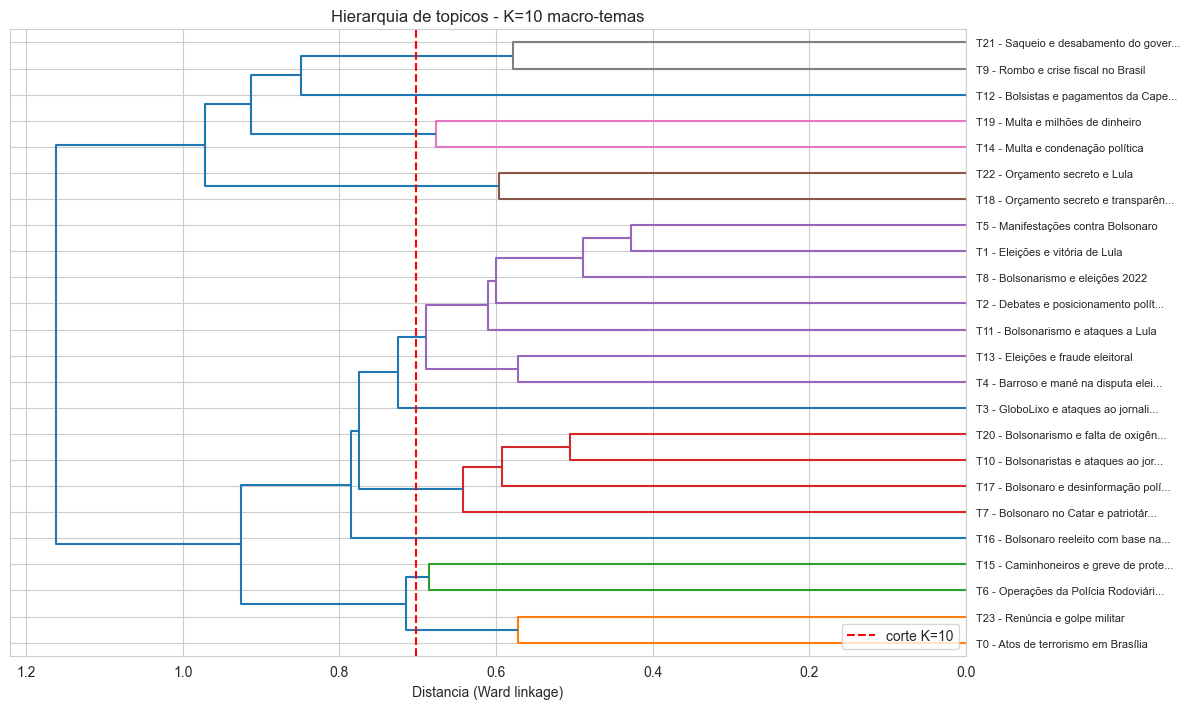

Salvo: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804\bertopic_arvore_macro.png


In [24]:
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from collections import defaultdict

# === R4 reescrito (NLP review): K *emergente* via maior salto na hierarquia ===
# Em vez de impor K=8, calculamos a linkage Ward sobre topic_embeddings_ e
# cortamos na MAIOR descontinuidade entre niveis. K vira data-driven, coerente
# com a filosofia "deixa o algoritmo descobrir" do BERTopic/HDBSCAN.

def _label_for(tid):
    if "names" in globals() and tid in names:
        return names[tid]
    kws = topics_keywords.get(tid, [])
    return ", ".join(kws[:3]) if kws else "T" + str(tid)


_doc_counts = pd.Series(topics).value_counts()
_doc_counts = _doc_counts[_doc_counts.index != -1]

if hasattr(topic_model, "topic_embeddings_") and topic_model.topic_embeddings_ is not None:
    valid_topic_ids = [t for t in sorted(topic_model.get_topics().keys()) if t != -1]
    topic_emb = topic_model.topic_embeddings_

    all_tids_sorted = sorted(topic_model.get_topics().keys())
    tid_to_idx = {t: i for i, t in enumerate(all_tids_sorted)}

    valid_emb = np.array([topic_emb[tid_to_idx[t]] for t in valid_topic_ids])

    norms = np.linalg.norm(valid_emb, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1.0, norms)
    valid_emb_norm = valid_emb / norms

    Z = linkage(valid_emb_norm, method="ward")

    # Maior gap entre distancias consecutivas dos merges (Z[:, 2] = distancia)
    merge_distances = Z[:, 2]
    macro_k = int(bert_cfg.get("macro_k", 8))
    macro_k = min(macro_k, len(valid_topic_ids) - 1)
    macro_labels = fcluster(Z, t=macro_k, criterion="maxclust")
    K_EMERGENT = macro_k
    cut_distance = (Z[-macro_k, 2] + Z[-(macro_k - 1), 2]) / 2.0 if macro_k >= 2 else Z[-1, 2] + 0.1

    print("=== Macro-temas (K fixo via params.yaml) ===")
    print("K macro-temas: " + str(K_EMERGENT))
    print()

    micro_to_macro = dict(zip(valid_topic_ids, macro_labels.tolist()))
    macro_to_micros = defaultdict(list)
    for micro, macro in micro_to_macro.items():
        macro_to_micros[macro].append(micro)

    for macro_id in sorted(macro_to_micros.keys()):
        micros = sorted(macro_to_micros[macro_id], key=lambda t: -int(_doc_counts.get(t, 0)))
        total_docs = sum(int(_doc_counts.get(t, 0)) for t in micros)

        macro_keywords = []
        for t in micros[:3]:
            macro_keywords.extend(topics_keywords.get(t, [])[:2])
        seen = set()
        macro_label_terms = []
        for kw in macro_keywords:
            if kw not in seen:
                seen.add(kw)
                macro_label_terms.append(kw)
        macro_label = ", ".join(macro_label_terms[:5])

        print("Macro-tema " + str(macro_id) + " (" + str(total_docs) + " docs, " + str(len(micros)) + " sub-topicos)")
        print("   Keywords agregadas: " + macro_label)
        for t in micros:
            n = int(_doc_counts.get(t, 0))
            label = _label_for(t)[:50]
            print("     T" + str(t).rjust(2) + " (" + str(n).rjust(4) + " docs)  " + label)
        print()

    macro_df = pd.DataFrame([
        {
            "topic_id": t,
            "macro_id": int(micro_to_macro[t]),
            "topic_name": _label_for(t),
            "n_docs": int(_doc_counts.get(t, 0)),
        }
        for t in valid_topic_ids
    ]).sort_values(["macro_id", "n_docs"], ascending=[True, False])
    macro_df.to_csv(RESULTS_DIR / "bertopic_macro_temas.csv", index=False)
    print("Salvo: " + str(RESULTS_DIR / "bertopic_macro_temas.csv"))

    fig, ax = plt.subplots(figsize=(12, max(6, 0.30 * len(valid_topic_ids))))
    labels_for_plot = []
    for t in valid_topic_ids:
        nm = _label_for(t)
        if len(nm) > 30:
            nm = nm[:30] + "..."
        labels_for_plot.append("T" + str(t) + " - " + nm)
    dendrogram(
        Z, labels=labels_for_plot, orientation="left",
        leaf_font_size=8, color_threshold=cut_distance, ax=ax,
    )
    ax.axvline(x=cut_distance, color="red", linestyle="--", linewidth=1.5,
               label="corte K=" + str(K_EMERGENT))
    ax.set_title("Hierarquia de topicos - K=" + str(K_EMERGENT) + " macro-temas")
    ax.set_xlabel("Distancia (Ward linkage)")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "bertopic_arvore_macro.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvo: " + str(RESULTS_DIR / "bertopic_arvore_macro.png"))
else:
    print("topic_embeddings_ indisponivel - pulando R4.")


## R4b — Sweep de macro_k

Corta o mesmo dendrograma (Ward, sem refit) em diferentes K e mostra a distribuição
de sub-tópicos por macro-tema. Permite escolher o K mais interpretável para apresentação.
Valores controlados por `evaluation.param_sweep_macro_k` no `params.yaml`.

In [25]:
macro_k_values = [int(k) for k in eval_cfg.get("param_sweep_macro_k", [4, 5, 6, 7, 8, 10, 12])]

if (hasattr(topic_model, "topic_embeddings_")
        and topic_model.topic_embeddings_ is not None
        and "valid_topic_ids" in globals()
        and "Z" in globals()
        and len(valid_topic_ids) >= 3):
    _sweep_rows_mk = []
    print("K  | sub-tópicos por macro-tema (decrescente por tamanho)")
    print("-" * 65)
    for k in macro_k_values:
        k_eff = min(k, len(valid_topic_ids) - 1)
        if k_eff < 2:
            continue
        lbl = fcluster(Z, t=k_eff, criterion="maxclust")
        m2m = defaultdict(list)
        for t, m in zip(valid_topic_ids, lbl):
            m2m[m].append(t)
        sizes = sorted([len(v) for v in m2m.values()], reverse=True)
        docs_per_macro = sorted(
            [sum(int(_doc_counts.get(t, 0)) for t in micros) for micros in m2m.values()],
            reverse=True,
        )
        suffix = "..." if len(docs_per_macro) > 5 else ""
        line = str(k_eff).rjust(2) + " | " + str(sizes) + "  (docs: " + str(docs_per_macro[:5]) + suffix + ")"
        print(line)
        _sweep_rows_mk.append({
            "macro_k": k_eff,
            "n_macros_real": len(sizes),
            "subtopics_dist": str(sizes),
            "min_subtopics": min(sizes),
            "max_subtopics": max(sizes),
            "docs_dist": str(docs_per_macro),
        })
    sweep_df_mk = pd.DataFrame(_sweep_rows_mk)
    out_sweep_mk = RESULTS_DIR / "bertopic_macro_k_sweep.csv"
    sweep_df_mk.to_csv(out_sweep_mk, index=False)
    print("")
    print("Salvo: " + str(out_sweep_mk))
    display(sweep_df_mk)
else:
    print("topic_embeddings_ indisponível ou tópicos insuficientes — pulando sweep macro_k.")

K  | sub-tópicos por macro-tema (decrescente por tamanho)
-----------------------------------------------------------------
 4 | [13, 5, 4, 2]  (docs: [4853, 2225, 682, 120])
 5 | [13, 4, 3, 2, 2]  (docs: [4853, 2225, 493, 189, 120])
 6 | [13, 4, 2, 2, 2, 1]  (docs: [4853, 2225, 340, 189, 153]...)
 7 | [12, 4, 2, 2, 2, 1, 1]  (docs: [4769, 2225, 340, 189, 153]...)
 8 | [8, 4, 4, 2, 2, 2, 1, 1]  (docs: [3978, 2225, 791, 340, 189]...)
10 | [7, 4, 2, 2, 2, 2, 2, 1, 1, 1]  (docs: [3437, 1722, 791, 541, 503]...)
12 | [5, 4, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1]  (docs: [2857, 1722, 791, 580, 541]...)

Salvo: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804\bertopic_macro_k_sweep.csv


,macro_k,n_macros_real,subtopics_dist,min_subtopics,max_subtopics,docs_dist
0,4,4,"[13, 5, 4, 2]",2,13,"[4853, 2225, 682, 120]"
1,5,5,"[13, 4, 3, 2, 2]",2,13,"[4853, 2225, 493, 189, 120]"
2,6,6,"[13, 4, 2, 2, 2, 1]",1,13,"[4853, 2225, 340, 189, 153, 120]"
3,7,7,"[12, 4, 2, 2, 2, 1, 1]",1,12,"[4769, 2225, 340, 189, 153, 120, 84]"
4,8,8,"[8, 4, 4, 2, 2, 2, 1, 1]",1,8,"[3978, 2225, 791, 340, 189, 153, 120, 84]"
5,10,10,"[7, 4, 2, 2, 2, 2, 2, 1, 1, 1]",1,7,"[3437, 1722, 791, 541, 503, 340, 189, 153, 120..."
6,12,12,"[5, 4, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1]",1,5,"[2857, 1722, 791, 580, 541, 405, 340, 189, 153..."


## V2 — Sankey: consolidação de tópicos pelo `reduce_topics`

Diagrama de Sankey mostrando como os tópicos descobertos pelo HDBSCAN foram
**consolidados** pelo `reduce_topics(nr_topics=N)`. Cada fluxo conecta um
tópico original a um tópico final, com largura proporcional ao número de
documentos.

Útil para a dissertação:
- Documenta visualmente a redução de granularidade (54 → 29 no run final)
- Mostra que tópicos "irmãos" foram absorvidos pelo mesmo cluster final
  (ex: 6 sub-tópicos de Segurança Pública → 1 tópico T3 consolidado)

Usa `topic_model.topic_mapper_.get_mappings()` para reconstruir o mapping.


In [26]:
try:
    import plotly.graph_objects as go
    mapper = getattr(topic_model, "topic_mapper_", None)
    mappings = mapper.get_mappings() if mapper else None
except Exception as _e:
    mappings = None

if mappings and len(mappings) > 0:
    # Mappings é um dict {topico_original: topico_final}
    # Excluir outliers (-1) se presentes
    flow_counts: dict = {}
    for tid_orig, tid_final in mappings.items():
        if tid_orig == -1 or tid_final == -1:
            continue
        flow_counts[(tid_orig, tid_final)] = flow_counts.get((tid_orig, tid_final), 0) + 1

    if flow_counts:
        # Para Sankey, usamos a contagem real de docs no tópico original (estimada)
        # como peso do fluxo. Sem essa info preservada, usamos contagem unitária.
        orig_ids = sorted({o for o, _ in flow_counts.keys()})
        final_ids = sorted({f for _, f in flow_counts.keys()})

        node_labels = (
            [f"orig T{t}" for t in orig_ids]
            + [f"final T{t} — {names.get(t, '')[:30]}" for t in final_ids]
        )
        orig_idx = {t: i for i, t in enumerate(orig_ids)}
        final_idx = {t: i + len(orig_ids) for i, t in enumerate(final_ids)}

        sources, targets, values = [], [], []
        for (o, f), v in flow_counts.items():
            sources.append(orig_idx[o])
            targets.append(final_idx[f])
            values.append(v)

        fig = go.Figure(data=[go.Sankey(
            arrangement="snap",
            node=dict(
                pad=15, thickness=18,
                line=dict(color="#888", width=0.5),
                label=node_labels,
                color="rgba(70, 130, 180, 0.7)",
            ),
            link=dict(source=sources, target=targets, value=values,
                      color="rgba(180, 180, 220, 0.4)"),
        )])
        fig.update_layout(
            title_text=f"Consolidação de tópicos: {len(orig_ids)} originais → {len(final_ids)} finais",
            font_size=10, height=max(500, 25 * max(len(orig_ids), len(final_ids))),
        )
        fig.write_html(RESULTS_DIR / "bertopic_sankey_reduce_topics.html")
        fig.show()
        print(f"Salvo: {RESULTS_DIR / 'bertopic_sankey_reduce_topics.html'}")
    else:
        print("V2: nenhum fluxo de redução encontrado (reduce_topics não foi aplicado).")
else:
    print("V2: topic_mapper_ vazio ou indisponível — reduce_topics não foi aplicado.")


Salvo: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804\bertopic_sankey_reduce_topics.html


## V7 — `visualize_documents` interativo com dropdown "Isolar tópico"

Versão **interativa Plotly** do mapa de documentos, com:
- Hover mostrando snippet do post
- **Dropdown** para isolar um tópico (esconde os outros) ou mostrar todos

Diferente da V6 (estática para PDF), a V7 é para exploração ao vivo —
útil para a defesa demonstrar tópicos sobrepostos ou validar atribuições.
Salvo em `bertopic_documents_interactive.html`.


In [27]:
import plotly.graph_objects as go

# Reutilizar embeddings dos docs (se BERTopic guardou) ou usar os ja carregados
doc_embeddings_for_v7 = embeddings

fig_docs_interactive = topic_model.visualize_documents(
    docs_raw if "docs_raw" in globals() else docs,
    embeddings=doc_embeddings_for_v7,
    hide_annotations=False,
    hide_document_hover=False,
)

# Adicionar dropdown "Isolar topico"
n_traces = len(fig_docs_interactive.data)
trace_names = [str(tr.name) for tr in fig_docs_interactive.data]

botoes = [dict(
    label="Todos os topicos",
    method="update",
    args=[{"visible": [True] * n_traces}],
)]

for i, name in enumerate(trace_names):
    visibility = [False] * n_traces
    visibility[i] = True
    botoes.append(dict(
        label=f"Isolar: {name[:40]}",
        method="update",
        args=[{"visible": visibility}],
    ))

fig_docs_interactive.update_layout(
    updatemenus=[dict(
        type="dropdown",
        direction="down",
        buttons=botoes,
        showactive=True,
        x=0.01, xanchor="left",
        y=1.12, yanchor="top",
        bgcolor="white",
        bordercolor="#888",
    )],
    annotations=list(fig_docs_interactive.layout.annotations or []) + [
        dict(
            text="<b>Isolar topico (dropdown)</b>",
            x=0.01, xref="paper",
            y=1.18, yref="paper",
            showarrow=False,
            font=dict(size=11),
        )
    ],
    margin=dict(t=120),
)

out_html_v7 = RESULTS_DIR / "bertopic_documents_interactive.html"
fig_docs_interactive.write_html(out_html_v7)
display(fig_docs_interactive)
print(f"Salvo: {out_html_v7}")


Salvo: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804\bertopic_documents_interactive.html


## Distribuição de docs por tópico (bar chart)

Mesma visualização usada na Folha — mostra quantos tweets foram atribuídos a cada
tópico, ordenados de forma decrescente, **excluindo outliers** (consistente com o
K=24 reportado). Gera `bertopic_docs_por_topico.png`.

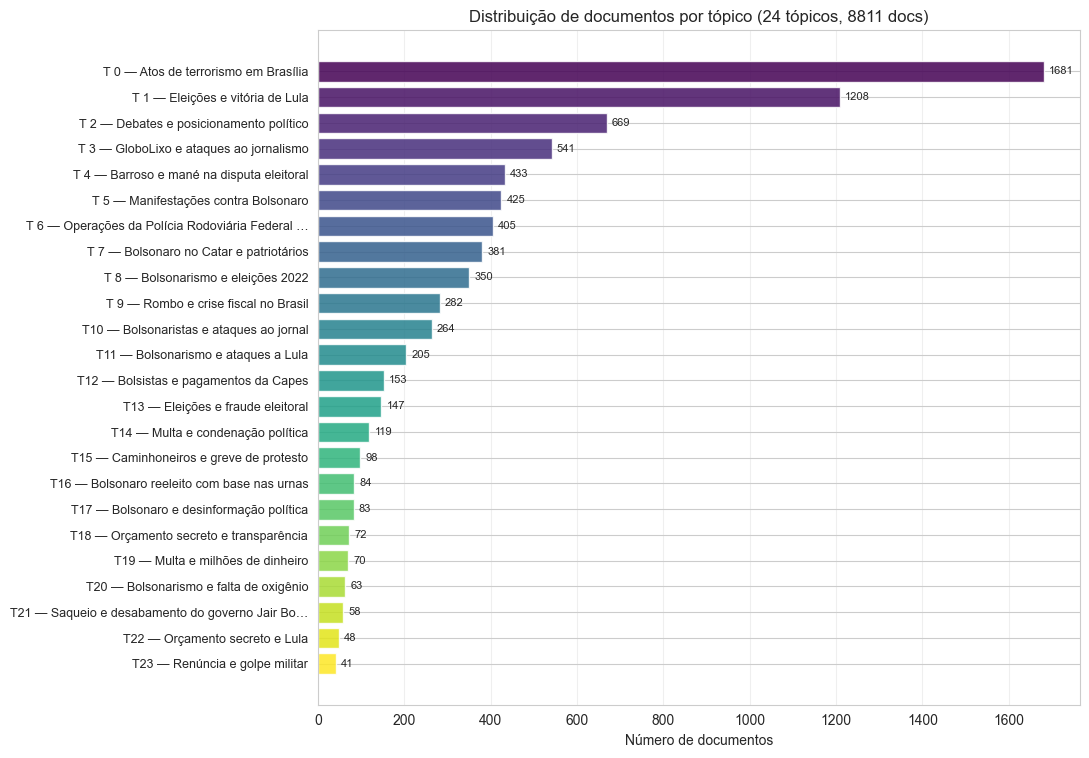

Salvo: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804\bertopic_docs_por_topico.png


In [28]:
import numpy as np
import matplotlib.pyplot as plt

doc_topic_counts = pd.Series(topics).value_counts().sort_values(ascending=False)
# Excluir outliers (-1) caso ainda existam
doc_topic_counts = doc_topic_counts[doc_topic_counts.index != -1]

labels = []
for tid in doc_topic_counts.index:
    name = topics_names.get(tid, _fallback_label(topics_keywords.get(tid, [])))
    name_short = (name[:40] + "…") if len(name) > 40 else name
    labels.append(f"T{tid:>2} — {name_short}")

n = len(doc_topic_counts)
fig, ax = plt.subplots(figsize=(11, max(5, 0.32 * n)))

cmap = plt.get_cmap("viridis", n)
colors = [cmap(i) for i in range(n)]

bars = ax.barh(range(n), doc_topic_counts.values, color=colors, alpha=0.85)
ax.set_yticks(range(n))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Número de documentos")
ax.set_title(f"Distribuição de documentos por tópico ({n} tópicos, {len(topics)} docs)")
ax.grid(True, axis="x", alpha=0.3)

for bar, val in zip(bars, doc_topic_counts.values):
    ax.text(bar.get_width() + n * 0.5, bar.get_y() + bar.get_height() / 2,
            f"{int(val)}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "bertopic_docs_por_topico.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvo: {RESULTS_DIR / 'bertopic_docs_por_topico.png'}")

## Agregação temporal

Se a coluna de data estiver presente no corpus, mostra a distribuição mensal
dos tópicos. Útil para análise narrativa ao longo do tempo (eixo opcional do
framework).


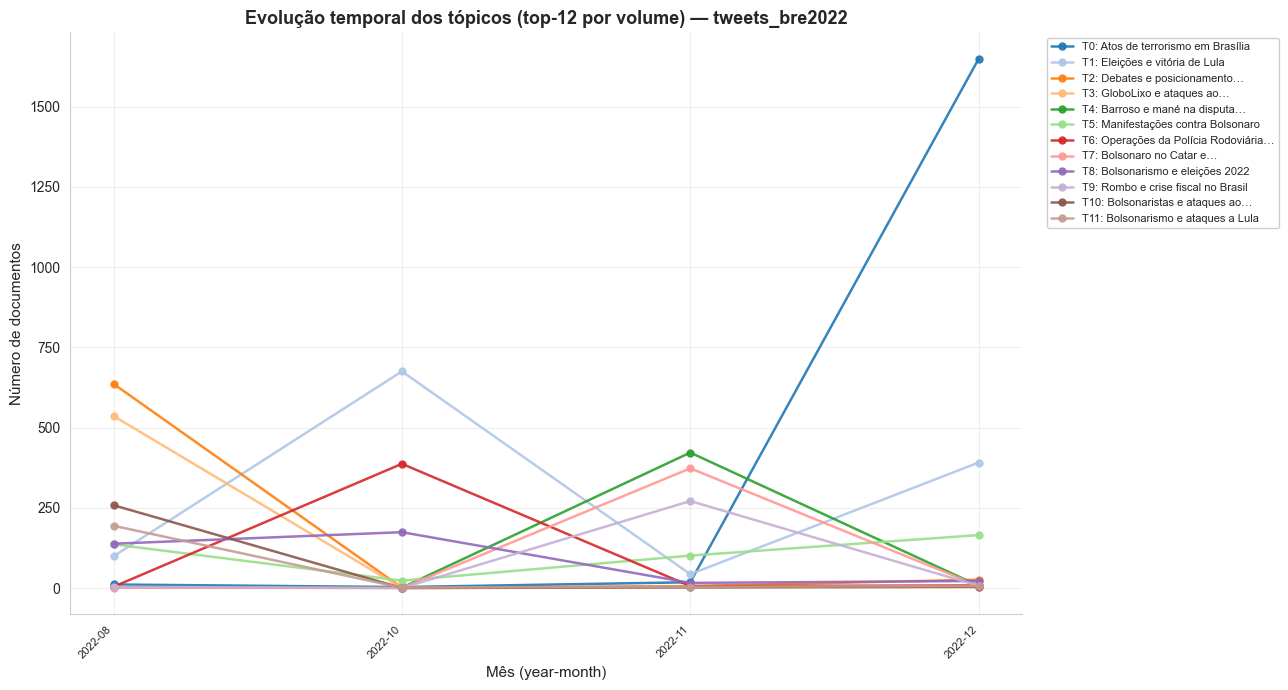

✓ Salvo: bertopic_evolucao_temporal.png (12 tópicos top)


In [29]:
DATE_COL = load_params()["corpora"][CORPUS_ID].get("date_column")  # tweets: "data"
corpus_id = CORPUS_ID  # celulas copiadas da folha usam o nome minusculo no titulo
import textwrap

TOP_N_TOPICS_TIMELINE = 12

if DATE_COL and DATE_COL in df.columns:
    df_temp = df.copy()
    df_temp["topic_id"] = topics
    df_temp[DATE_COL] = pd.to_datetime(df_temp[DATE_COL], errors="coerce", dayfirst=True)
    df_temp["year_month"] = df_temp[DATE_COL].dt.to_period("M").astype(str)
    df_temp = df_temp[df_temp["topic_id"] != -1]

    pivot = (
        df_temp.groupby(["year_month", "topic_id"]).size()
        .unstack(fill_value=0).sort_index()
    )

    # Limitar aos top-N tópicos por volume total (evitar poluição visual com 30+ linhas)
    top_topics = pivot.sum(axis=0).sort_values(ascending=False).head(TOP_N_TOPICS_TIMELINE).index.tolist()
    pivot = pivot[top_topics]

    cmap_t = plt.get_cmap("tab20")
    fig, ax = plt.subplots(figsize=(13, 7))
    for i, tid in enumerate(top_topics):
        label = f"T{tid}: {textwrap.shorten(topics_names.get(tid, ''), width=32, placeholder='…')}"
        ax.plot(pivot.index, pivot[tid], marker="o", linewidth=1.8,
                markersize=5, color=cmap_t(i % 20), label=label, alpha=0.9)

    ax.set_title(f"Evolução temporal dos tópicos (top-{TOP_N_TOPICS_TIMELINE} por volume) — {corpus_id}",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Mês (year-month)", fontsize=11)
    ax.set_ylabel("Número de documentos", fontsize=11)
    ax.grid(alpha=0.3); ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, framealpha=0.95)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "bertopic_evolucao_temporal.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"✓ Salvo: bertopic_evolucao_temporal.png ({TOP_N_TOPICS_TIMELINE} tópicos top)")
else:
    print(f"Coluna '{DATE_COL}' indisponível — agregação pulada.")


## V3 — Heatmap temporal: mês × tópico

Matriz colorida onde cada célula é a **proporção de posts** de um tópico em um
mês específico. Permite identificar:

- **Sazonalidades** óbvias (Carnaval em fev/mar, São João em jun, eleições
  em out)
- **Picos de agenda** — quando uma política pública dominou a comunicação
- **Tópicos persistentes** vs **tópicos episódicos**

Complementar ao stacked area `bertopic_evolucao_temporal.png` — esse é mais
fácil de ler para tópicos individuais com pouca prevalência.

Salvo como `bertopic_heatmap_temporal.png`.


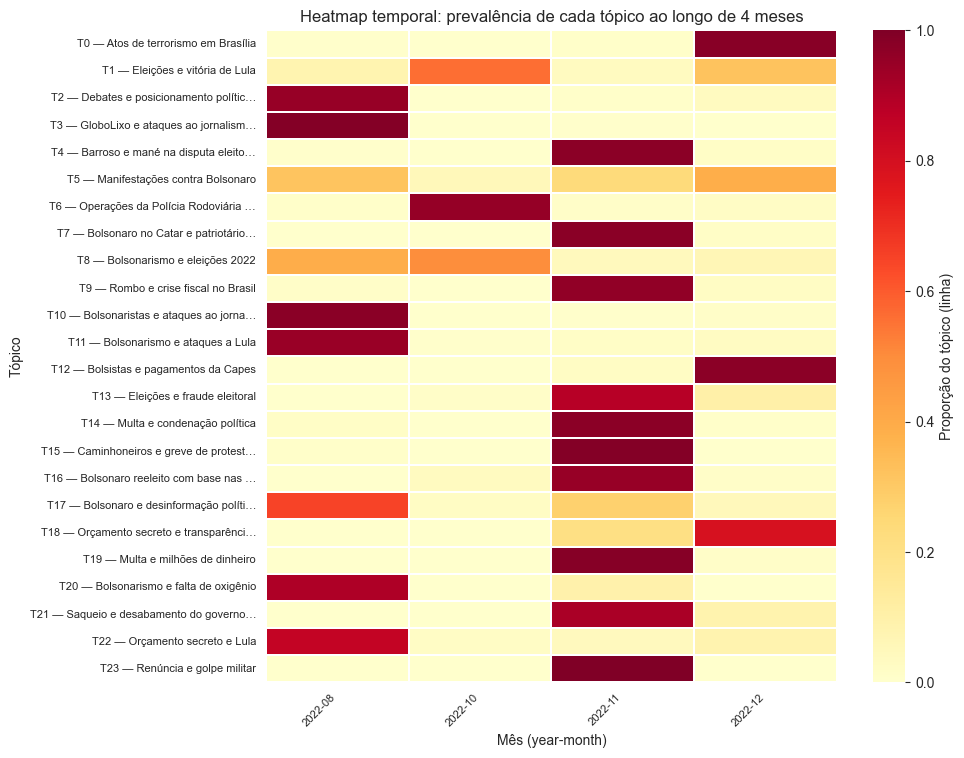

Salvo: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804\bertopic_heatmap_temporal.png


In [30]:
if DATE_COL and DATE_COL in df.columns and len(topics_keywords) >= 2:
    df_temp = df.copy()
    df_temp["topic_id"] = topics
    df_temp[DATE_COL] = pd.to_datetime(df_temp[DATE_COL], errors="coerce", dayfirst=True)
    df_temp["year_month"] = df_temp[DATE_COL].dt.to_period("M").astype(str)
    df_temp = df_temp[df_temp["topic_id"] != -1]

    # Pivot: linhas = tópicos, colunas = meses, valores = contagem
    pivot = df_temp.pivot_table(
        index="topic_id", columns="year_month",
        values="post_id" if "post_id" in df_temp.columns else DATE_COL,
        aggfunc="count", fill_value=0,
    )

    # Normalizar por LINHA (proporção dentro de cada tópico ao longo dos meses)
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0).fillna(0)

    # Rótulos com nome LLM
    pivot_norm.index = [
        f"T{tid} — {(topics_names.get(tid, '')[:32] + '…') if len(topics_names.get(tid, '')) > 32 else topics_names.get(tid, '')}"
        for tid in pivot_norm.index
    ]

    fig, ax = plt.subplots(figsize=(max(10, 0.4 * pivot_norm.shape[1]),
                                     max(6, 0.32 * pivot_norm.shape[0])))
    sns.heatmap(
        pivot_norm, cmap="YlOrRd", annot=False, cbar_kws={"label": "Proporção do tópico (linha)"},
        linewidths=0.3, linecolor="white", ax=ax,
    )
    ax.set_title(f"Heatmap temporal: prevalência de cada tópico ao longo de {pivot_norm.shape[1]} meses")
    ax.set_xlabel("Mês (year-month)")
    ax.set_ylabel("Tópico")
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "bertopic_heatmap_temporal.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Salvo: {RESULTS_DIR / 'bertopic_heatmap_temporal.png'}")
else:
    print(f"V3: pulado (sem coluna de data ou poucos tópicos)")


## V4 — Evolução temporal por tópico (linhas com smoothing)

Para cada tópico, plota a contagem de posts por mês como linha com **rolling
mean de 3 meses** (suavização leve). Útil para identificar:

- **Tendências de longo prazo** (crescimento/queda de uma agenda)
- **Eventos específicos** (picos isolados em meses individuais)
- **Tópicos cíclicos** (Carnaval/São João todo ano)

Em vez de stack/área, cada tópico tem seu painel próprio para legibilidade.
Mostra os top-N tópicos por nº de docs.


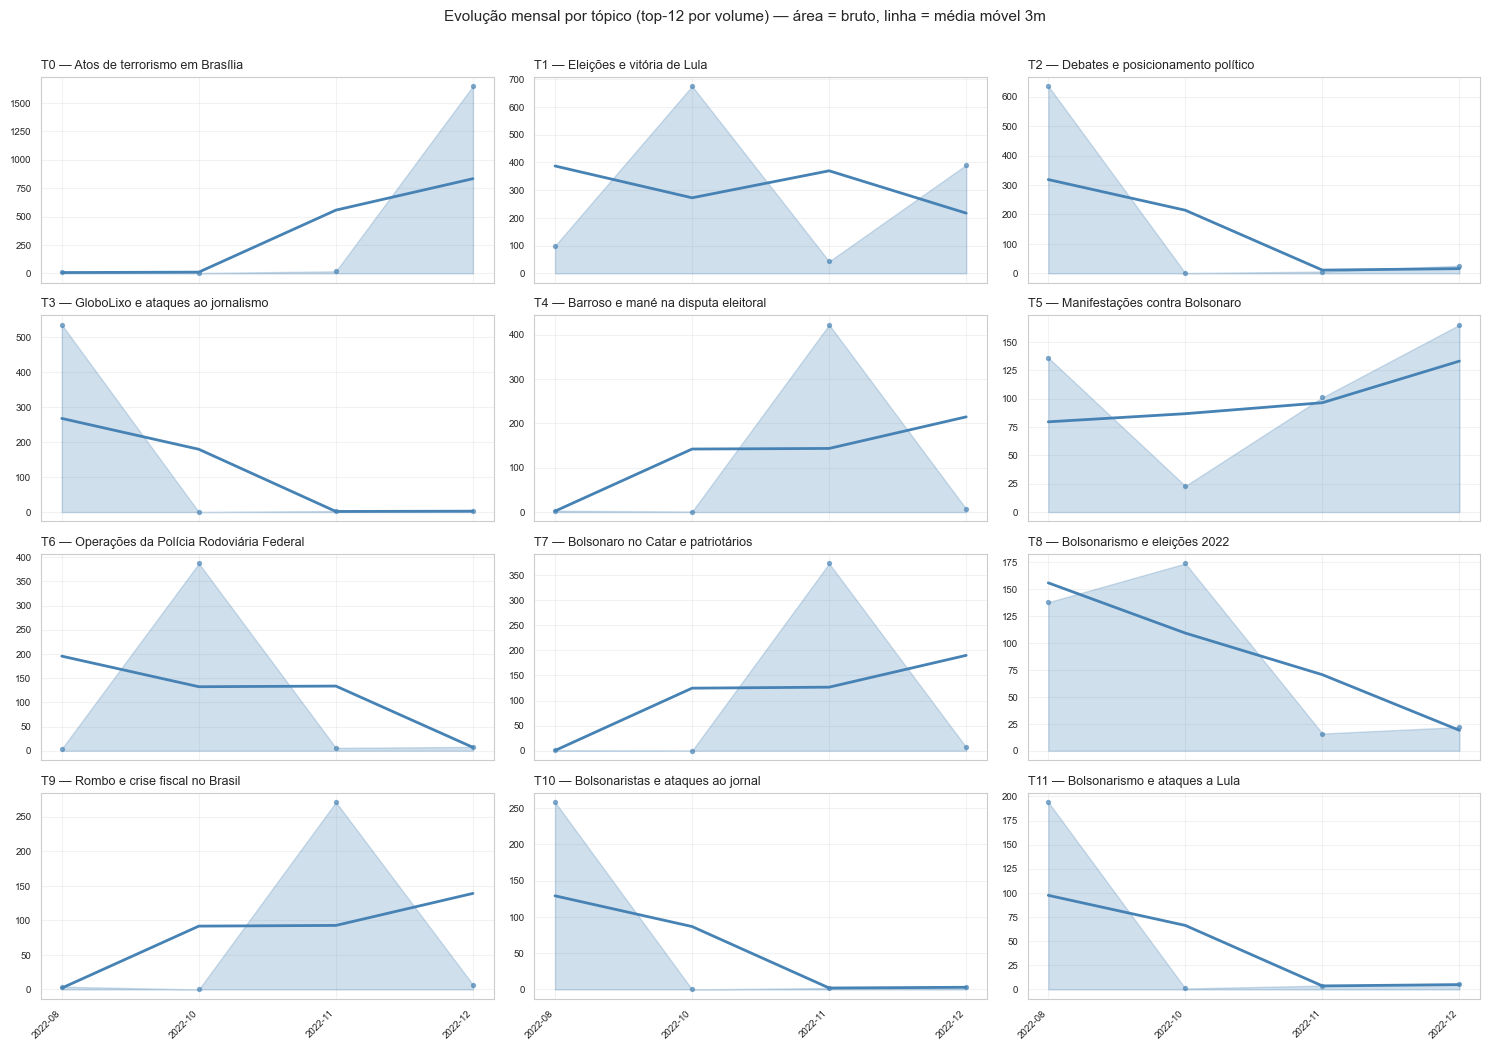

Salvo: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804\bertopic_evolucao_por_topico.png


In [31]:
N_TOP = 12  # quantos tópicos plotar (limita altura da figura)

if DATE_COL and DATE_COL in df.columns and len(topics_keywords) >= 2:
    df_temp = df.copy()
    df_temp["topic_id"] = topics
    df_temp[DATE_COL] = pd.to_datetime(df_temp[DATE_COL], errors="coerce", dayfirst=True)
    df_temp["year_month"] = df_temp[DATE_COL].dt.to_period("M").astype(str)
    df_temp = df_temp[df_temp["topic_id"] != -1]

    counts_per_month = df_temp.pivot_table(
        index="year_month", columns="topic_id",
        values="post_id" if "post_id" in df_temp.columns else DATE_COL,
        aggfunc="count", fill_value=0,
    ).sort_index()

    # Top-N tópicos por contagem total
    top_topics = counts_per_month.sum(axis=0).sort_values(ascending=False).head(N_TOP).index.tolist()

    cols_grid = 3
    rows_grid = (len(top_topics) + cols_grid - 1) // cols_grid
    fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(15, 2.6 * rows_grid),
                              sharex=True)
    axes = np.atleast_1d(axes).flatten()

    x_idx = range(len(counts_per_month.index))

    for ax, tid in zip(axes, top_topics):
        series = counts_per_month[tid]
        rolling = series.rolling(window=3, min_periods=1, center=True).mean()

        ax.fill_between(x_idx, 0, series.values, color="steelblue", alpha=0.25)
        ax.plot(x_idx, rolling.values, color="steelblue", linewidth=2.0, label="rolling-3m")
        ax.scatter(x_idx, series.values, color="steelblue", s=8, alpha=0.6)

        name = topics_names.get(tid, "")[:40]
        ax.set_title(f"T{tid} — {name}", fontsize=9, loc="left")
        ax.tick_params(axis="x", labelsize=7, rotation=45)
        ax.tick_params(axis="y", labelsize=7)
        ax.grid(True, alpha=0.25)
        ax.set_xticks(x_idx[::max(1, len(x_idx) // 6)])
        ax.set_xticklabels(
            [counts_per_month.index[i] for i in x_idx[::max(1, len(x_idx) // 6)]],
            ha="right", fontsize=7,
        )

    for ax in axes[len(top_topics):]:
        ax.axis("off")

    plt.suptitle(f"Evolução mensal por tópico (top-{len(top_topics)} por volume) — área = bruto, linha = média móvel 3m",
                  fontsize=11, y=1.005)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "bertopic_evolucao_por_topico.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Salvo: {RESULTS_DIR / 'bertopic_evolucao_por_topico.png'}")
else:
    print("V4: pulado (sem coluna de data ou poucos tópicos)")


## Robustez das métricas vs top-N de keywords

Verifica se os scores obtidos com `top_n=10` são representativos do modelo completo.
Métricas estáveis (plateau) → top-10 é suficiente para reportar.
Queda abrupta → os números top-10 estão inflados pela cauda longa.

Salva `bertopic_robustness_topn.csv` para inclusão na dissertação.

=== Sweep de robustez (métricas vs top-N) ===
 top_n   NPMI    C_v  Topic_Diversity  Sem_Coherence  Exclusivity  FREX
    10 0.1869 0.6919             0.90         0.6697       0.7397 0.983
    15 0.1869 0.6919             0.60         0.6697       0.7397 0.983
    20 0.1869 0.6919             0.45         0.6697       0.7397 0.983
    25 0.1869 0.6919             0.36         0.6698       0.7397 0.983
    30 0.1869 0.6919             0.30         0.6698       0.7397 0.983
    50 0.1869 0.6919             0.18         0.6697       0.7397 0.983
   100 0.1869 0.6919             0.09         0.6698       0.7397 0.983


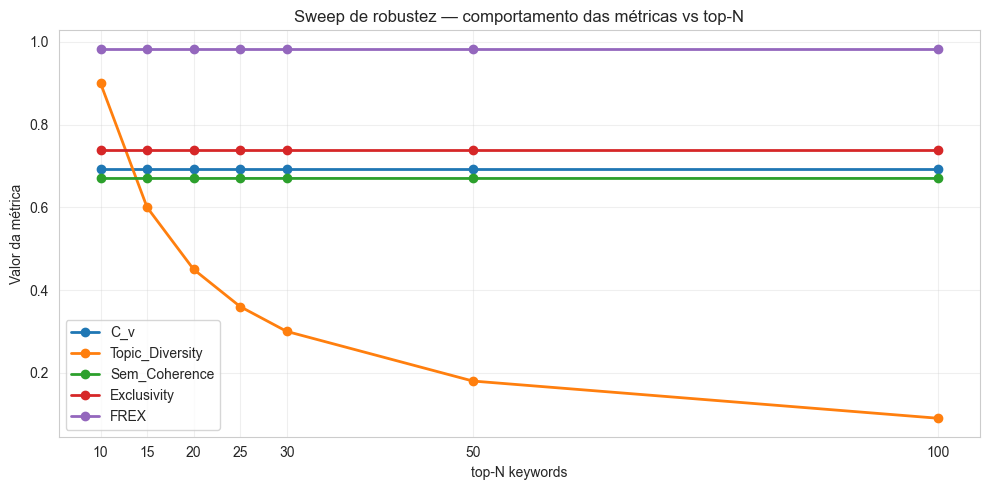


Salvo: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804\bertopic_robustness_topn.csv
Salvo: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804\bertopic_robustness_topn.png


In [32]:
sweep_values_topn = eval_cfg.get("robustness_top_n_sweep", [10, 15, 20, 25, 30, 50, 100])
_sweep_rows_topn = []

for top_n_sw in sweep_values_topn:
    kws_at_n = {tid: kws[:top_n_sw] for tid, kws in topics_keywords_ctfidf.items()}

    td_n = compute_topic_diversity(kws_at_n, top_k=top_n_sw)

    try:
        cv_n = float(compute_coherence_cv(kws_at_n, tokenized, dictionary))
    except Exception:
        cv_n = float("nan")

    try:
        npmi_n = float(compute_coherence_npmi(kws_at_n, tokenized, dictionary))
    except Exception:
        npmi_n = float("nan")

    try:
        sem_n = float(compute_embedding_coherence(kws_at_n, _embed))
    except Exception:
        sem_n = float("nan")

    excl_n_mean, _ = compute_exclusivity_ctfidf(topics_keywords_ctfidf, topic_word_scores, top_n=top_n_sw)

    frex_n_mean, _ = compute_frex_score(
        topics_keywords_ctfidf, topic_word_matrix=ctfidf_matrix,
        vocab_index=vocab_index, topic_index=topic_index,
        top_n=top_n_sw, w_freq=0.5,
    )

    _sweep_rows_topn.append({
        "top_n": top_n_sw,
        "NPMI": npmi_n,
        "C_v": cv_n,
        "Topic_Diversity": td_n,
        "Sem_Coherence": sem_n,
        "Exclusivity": excl_n_mean,
        "FREX": frex_n_mean,
    })

sweep_df_topn = pd.DataFrame(_sweep_rows_topn).round(4)
sweep_df_topn.to_csv(RESULTS_DIR / "bertopic_robustness_topn.csv", index=False)

print("=== Sweep de robustez (métricas vs top-N) ===")
print(sweep_df_topn.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
for col in ["C_v", "Topic_Diversity", "Sem_Coherence", "Exclusivity", "FREX"]:
    ax.plot(sweep_df_topn["top_n"], sweep_df_topn[col], marker="o", label=col, linewidth=2)
ax.set_xlabel("top-N keywords")
ax.set_ylabel("Valor da métrica")
ax.set_title("Sweep de robustez — comportamento das métricas vs top-N")
ax.legend(loc="best")
ax.grid(True, alpha=0.3)
ax.set_xticks(sweep_values_topn)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "bertopic_robustness_topn.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nSalvo: {RESULTS_DIR / 'bertopic_robustness_topn.csv'}")
print(f"Salvo: {RESULTS_DIR / 'bertopic_robustness_topn.png'}")

## 11. Export final

In [33]:
# Cell 18 — Export CSVs + model
out_dir = str(RESULTS_DIR)
os.makedirs(out_dir, exist_ok=True)

probs_dummy = [[1.0 if t == tid else 0.0 for tid in sorted(topics_keywords)] for t in topics]
topic_id_for_export = [t if t != -1 else max(topics_keywords) + 1 for t in topics]
names_export = dict(names)
names_export[max(topics_keywords) + 1] = "Outlier"

export_results(
    topics=topic_id_for_export, probs=probs_dummy, names=names_export,
    texts=docs, output_path=f"{out_dir}/bertopic_results.csv",
    topic_type="semantic", granularity="unit", post_ids=post_ids,
)
export_topics_for_eval(
    topics_keywords=topics_keywords, topics_names=names,
    model_name="bertopic", output_path=f"{out_dir}/bertopic_topics_for_eval.csv",
)
pd.DataFrame([metrics]).to_csv(f"{out_dir}/bertopic_metrics.csv", index=False)

try:
    topic_model.save(f"{out_dir}/bertopic_model",
                     serialization="safetensors", save_ctfidf=True, save_embedding_model=False)
    print(f"saved model: {out_dir}/bertopic_model/")
except Exception as e:
    print(f"model save: {e}")

print(f"\nCSVs em {out_dir}/")
for fname in [
    "bertopic_results.csv", "bertopic_topics_for_eval.csv", "bertopic_metrics.csv",
    "bertopic_topic_names.csv", "bertopic_exclusividade_ranking.csv",
    "bertopic_macro_temas.csv", "bertopic_macro_k_sweep.csv",
    "bertopic_robustness_topn.csv",
]:
    p = f"{out_dir}/{fname}"
    if os.path.exists(p):
        print(f"  {fname} ({os.path.getsize(p)/1024:.0f} KB)")
    else:
        print(f"  {fname} (não gerado)")

2026-08-29 11:51:53,492 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


saved model: ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804/bertopic_model/

CSVs em ..\data\output\tweets_bre2022\bertopic\tweets_bre2022_20260829_112804/
  bertopic_results.csv (3083 KB)
  bertopic_topics_for_eval.csv (10 KB)
  bertopic_metrics.csv (0 KB)
  bertopic_topic_names.csv (1 KB)
  bertopic_exclusividade_ranking.csv (1 KB)
  bertopic_macro_temas.csv (1 KB)
  bertopic_macro_k_sweep.csv (1 KB)
  bertopic_robustness_topn.csv (0 KB)


## 12. Próximos passos

- Identificar tópicos concentrados em períodos eleitorais específicos (cruzamento com ground-truth temporal)
- Cruzar tópicos × sentimento via `post_id` (consome `03-sentiment/data/output/<corpus>/sentiment_results.csv`)

## Referências

- **Raniere, L. et al. (2024)**. *2022 Brazilian Presidential Elections Tweets Dataset*. Zenodo. DOI: 10.5281/zenodo.14834749
- **Grootendorst, M. (2022)**. *BERTopic*. arXiv:2203.05794
- **McInnes, L., Healy, J. (2018)**. *UMAP*
- **Campello, R. J. G. B. et al. (2013)**. *HDBSCAN*


In [34]:
print("kernel check ok")

kernel check ok


In [35]:
print(len(dir()))
print([v for v in dir() if not v.startswith('_')][:20])

427
['BASE_RESULTS_DIR', 'BERTopic', 'CORPUS_ID', 'CountVectorizer', 'DATE_COL', 'FEW_SHOT_EXAMPLES', 'HDBSCAN', 'In', 'K', 'K_EMERGENT', 'MaximalMarginalRelevance', 'N_PALAVRAS', 'N_REPR_DOCS', 'N_TOP', 'Out', 'PS1', 'Path', 'REPLHooks', 'RESULTS_DIR', 'TEXT_COL']


In [36]:
# cell 2
# ── path fix: resolve _helpers.py e data/ de qualquer subdiretório ──
import sys, os
from pathlib import Path

_here = Path.cwd()
for _p in [_here, *_here.parents]:
    if (_p / "_helpers.py").exists():
        sys.path.insert(0, str(_p))
        os.chdir(_p)
        break
print("cwd:", Path.cwd())

cwd: D:\Área de Trabalho\UPE\1 Período\PLN\Topic Modeling - LDA and BERTopic\03-topic-modeling\notebooks


In [37]:
print("kernel ativo — pronto para acompanhar")

kernel ativo — pronto para acompanhar


In [38]:
_needed = ["topic_model","topics_keywords","emb_model","bert_cfg","eval_cfg"]
print({v: (v in dir()) for v in _needed})

{'topic_model': True, 'topics_keywords': True, 'emb_model': True, 'bert_cfg': True, 'eval_cfg': True}


In [39]:
_needed = ["topic_model","topics_keywords","docs","embeddings","tokenized","dictionary","eval_cfg","bert_cfg","RESULTS_DIR"]
print({v: (v in dir()) for v in _needed})

{'topic_model': True, 'topics_keywords': True, 'docs': True, 'embeddings': True, 'tokenized': True, 'dictionary': True, 'eval_cfg': True, 'bert_cfg': True, 'RESULTS_DIR': True}


In [40]:
import importlib, _helpers
importlib.reload(_helpers)
from _helpers import sweep_outlier_strategies, sweep_outlier_threshold, sweep_bertopic_grid
print("reload OK — _helpers atualizado no kernel")

reload OK — _helpers atualizado no kernel
